# Step 18 — SHAP Analysis by Demand Type

## Purpose

This notebook examines how the final XGBoost models used individual features when producing the recursive 28-day forecasts.

The analysis covers the 20 complete models developed in Step 16:

- five walk-forward folds;
- four demand types;
- 112,000 untouched outer-test forecasts.

The recursive feature values are reconstructed using observed training sales and stored predictions from earlier forecast horizons. Actual test-period sales are not used to construct lag or rolling features.

Native XGBoost TreeSHAP contributions are calculated for every outer-test forecast. Feature importance is first calculated separately for each fold and demand type. Normalised importance shares are then averaged across folds to support comparison between demand types.

SHAP values explain how the fitted models used the available features. They do not establish causal effects and do not directly measure whether a feature improved forecast accuracy.

The SHAP contributions are calculated on the XGBoost model-margin scale. They should not be interpreted as direct changes in unit sales.

In [1]:
# Cell 1: Environment and project paths

from pathlib import Path

import gc
import os
import time
import warnings

import numpy as np
import pandas as pd
import xgboost as xgb

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

CURRENT_DIRECTORY = Path.cwd().resolve()

if CURRENT_DIRECTORY.name.lower() == "notebooks":
    PROJECT_ROOT = CURRENT_DIRECTORY.parent
else:
    PROJECT_ROOT = CURRENT_DIRECTORY

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DATA_DIR = DATA_DIR / "processed"

MODEL_DIR = PROJECT_ROOT / "models"
STEP16_MODEL_DIR = MODEL_DIR / "step16"

OUTPUT_DIR = PROJECT_ROOT / "outputs"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"
MODEL_RESULTS_DIR = OUTPUT_DIR / "model_results"

STEP16_TABLE_DIR = TABLE_DIR / "step16"

STEP18_TABLE_DIR = TABLE_DIR / "step18"
STEP18_FIGURE_DIR = FIGURE_DIR / "step18"
STEP18_RESULT_DIR = MODEL_RESULTS_DIR / "step18"

STEP18_TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

STEP18_FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

STEP18_RESULT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

MODELLING_DATA_FILE = (
    PROCESSED_DATA_DIR
    / "modelling_dataset.parquet"
)

STEP16_RESULTS_FILE = (
    STEP16_TABLE_DIR
    / "step16_xgb_fold_results.csv"
)

STEP16_PREDICTIONS_FILE = (
    MODEL_RESULTS_DIR
    / "step16_xgb_predictions.parquet"
)

N_THREADS = max(
    1,
    min(
        8,
        os.cpu_count() or 1,
    ),
)

required_paths = [
    PROJECT_ROOT,
    MODELLING_DATA_FILE,
    STEP16_RESULTS_FILE,
    STEP16_PREDICTIONS_FILE,
    STEP16_MODEL_DIR,
]

missing_paths = [
    path
    for path in required_paths
    if not path.exists()
]

print("Step 18 environment")
print("-" * 70)
print(f"Project root: {PROJECT_ROOT}")
print(f"XGBoost version: {xgb.__version__}")
print(f"Random seed: {SEED}")
print(f"CPU threads: {N_THREADS}")
print(f"Step 16 model directory: {STEP16_MODEL_DIR}")
print(f"Step 18 table directory: {STEP18_TABLE_DIR}")
print(f"Step 18 figure directory: {STEP18_FIGURE_DIR}")

if missing_paths:
    raise FileNotFoundError(
        "The following Step 18 inputs are missing:\n- "
        + "\n- ".join(
            str(path)
            for path in missing_paths
        )
    )

print("\nEnvironment and path checks passed.")

Step 18 environment
----------------------------------------------------------------------
Project root: C:\Users\gamec\Documents\MSc_Dissertation_M5
XGBoost version: 3.3.0
Random seed: 42
CPU threads: 8
Step 16 model directory: C:\Users\gamec\Documents\MSc_Dissertation_M5\models\step16
Step 18 table directory: C:\Users\gamec\Documents\MSc_Dissertation_M5\outputs\tables\step18
Step 18 figure directory: C:\Users\gamec\Documents\MSc_Dissertation_M5\outputs\figures\step18

Environment and path checks passed.


In [2]:
# Cell 2: Load the final model data and predictions

load_start = time.perf_counter()

model_df = pd.read_parquet(
    MODELLING_DATA_FILE
)

step16_fold_results = pd.read_csv(
    STEP16_RESULTS_FILE,
    parse_dates=[
        "train_end",
        "test_start",
        "test_end",
    ],
)

step16_predictions = pd.read_parquet(
    STEP16_PREDICTIONS_FILE
)

load_seconds = (
    time.perf_counter()
    - load_start
)

SERIES_COLUMN = "id"
DATE_COLUMN = "date"
TARGET_COLUMN = "sales"
DEMAND_TYPE_COLUMN = "demand_type"

model_df[DATE_COLUMN] = pd.to_datetime(
    model_df[DATE_COLUMN]
)

step16_predictions[DATE_COLUMN] = pd.to_datetime(
    step16_predictions[DATE_COLUMN]
)

model_df[SERIES_COLUMN] = (
    model_df[SERIES_COLUMN]
    .astype(str)
)

step16_predictions[SERIES_COLUMN] = (
    step16_predictions[SERIES_COLUMN]
    .astype(str)
)

DEMAND_TYPES = [
    "smooth",
    "erratic",
    "intermittent",
    "lumpy",
]

LAG_FEATURES = [
    "lag_7",
    "lag_14",
    "lag_28",
    "lag_56",
]

ROLLING_FEATURES = [
    "rolling_mean_7",
    "rolling_std_7",
    "rolling_mean_28",
    "rolling_std_28",
]

CALENDAR_FEATURES = [
    "is_weekend",
    "weekday",
    "month",
    "year",
]

EVENT_SNAP_FEATURES = [
    "event_flag",
    "event_type_encoded",
    "snap_flag",
]

PRICE_FEATURES = [
    "sell_price",
    "price_change",
    "price_vs_28d_avg",
]

FEATURE_GROUPS = {
    "lag": LAG_FEATURES,
    "rolling": ROLLING_FEATURES,
    "calendar": CALENDAR_FEATURES,
    "event_snap": EVENT_SNAP_FEATURES,
    "price": PRICE_FEATURES,
}

SALES_HISTORY_FEATURES = (
    LAG_FEATURES
    + ROLLING_FEATURES
)

SCHEDULED_FEATURES = (
    CALENDAR_FEATURES
    + EVENT_SNAP_FEATURES
    + PRICE_FEATURES
)

FULL_MODEL_FEATURES = (
    SALES_HISTORY_FEATURES
    + SCHEDULED_FEATURES
)

FEATURE_TO_GROUP = {
    feature: group_name
    for group_name, features
    in FEATURE_GROUPS.items()
    for feature in features
}

prediction_group_audit = (
    step16_predictions
    .groupby(
        [
            "fold",
            DEMAND_TYPE_COLUMN,
        ],
        observed=True,
        as_index=False,
    )
    .agg(
        prediction_rows=(
            "xgb_forecast",
            "size",
        ),
        series_count=(
            SERIES_COLUMN,
            "nunique",
        ),
        test_dates=(
            DATE_COLUMN,
            "nunique",
        ),
    )
)

input_checks = {
    "1,552,800 modelling rows": (
        len(model_df) == 1_552_800
    ),
    "20 final model results": (
        len(step16_fold_results) == 20
    ),
    "112,000 stored forecasts": (
        len(step16_predictions) == 112_000
    ),
    "800 unique series": (
        step16_predictions[
            SERIES_COLUMN
        ].nunique() == 800
    ),
    "20 fold-demand groups": (
        len(prediction_group_audit) == 20
    ),
    "5,600 predictions per group": (
        prediction_group_audit[
            "prediction_rows"
        ].eq(5_600).all()
    ),
    "200 series per group": (
        prediction_group_audit[
            "series_count"
        ].eq(200).all()
    ),
    "28 test dates per group": (
        prediction_group_audit[
            "test_dates"
        ].eq(28).all()
    ),
    "18 complete-model features": (
        len(FULL_MODEL_FEATURES) == 18
    ),
    "All model features exist": (
        set(FULL_MODEL_FEATURES)
        .issubset(model_df.columns)
    ),
    "No duplicate stored forecasts": (
        step16_predictions
        .duplicated(
            subset=[
                "fold",
                DEMAND_TYPE_COLUMN,
                SERIES_COLUMN,
                DATE_COLUMN,
            ]
        )
        .sum() == 0
    ),
    "No missing stored forecasts": (
        step16_predictions[
            "xgb_forecast"
        ].isna().sum() == 0
    ),
    "No non-finite stored forecasts": (
        np.isfinite(
            step16_predictions[
                "xgb_forecast"
            ].to_numpy()
        ).all()
    ),
    "No negative stored forecasts": (
        (
            step16_predictions[
                "xgb_forecast"
            ] < 0
        ).sum() == 0
    ),
    "Target excluded from model features": (
        TARGET_COLUMN
        not in FULL_MODEL_FEATURES
    ),
}

input_check_table = pd.DataFrame(
    {
        "check": input_checks.keys(),
        "passed": input_checks.values(),
    }
)

print("Loaded Step 18 inputs")
print("-" * 70)
print(f"Modelling rows: {len(model_df):,}")
print(
    f"Step 16 result rows: "
    f"{len(step16_fold_results):,}"
)
print(
    f"Step 16 prediction rows: "
    f"{len(step16_predictions):,}"
)
print(
    f"Complete-model features: "
    f"{len(FULL_MODEL_FEATURES)}"
)
print(f"Load time: {load_seconds:.2f} seconds")

display(input_check_table)

failed_input_checks = [
    check
    for check, passed
    in input_checks.items()
    if not passed
]

if failed_input_checks:
    raise AssertionError(
        "Step 18 input audit failed:\n- "
        + "\n- ".join(
            failed_input_checks
        )
    )

print("\nStep 18 input audit passed.")

Loaded Step 18 inputs
----------------------------------------------------------------------
Modelling rows: 1,552,800
Step 16 result rows: 20
Step 16 prediction rows: 112,000
Complete-model features: 18
Load time: 0.50 seconds


,check,passed
0,"1,552,800 modelling rows",True
1,20 final model results,True
2,"112,000 stored forecasts",True
3,800 unique series,True
4,20 fold-demand groups,True
5,"5,600 predictions per group",True
6,200 series per group,True
7,28 test dates per group,True
8,18 complete-model features,True
9,All model features exist,True



Step 18 input audit passed.


In [3]:
# Cell 3: Find and audit the 20 final Step 16 models

MODEL_SUFFIXES = {
    ".ubj",
    ".json",
    ".model",
    ".bin",
}

available_model_files = [
    path
    for path in STEP16_MODEL_DIR.rglob("*")
    if (
        path.is_file()
        and path.suffix.lower()
        in MODEL_SUFFIXES
    )
]


def resolve_model_file(
    fold_number,
    demand_type,
):
    """
    Find one Step 16 model using its fold number and demand type.
    """

    demand_label = str(
        demand_type
    ).lower()

    fold_tokens = {
        f"fold{fold_number}",
        f"fold_{fold_number}",
        f"fold-{fold_number}",
    }

    matching_files = []

    for model_path in available_model_files:
        model_name = (
            model_path.stem
            .lower()
        )

        fold_matches = any(
            token in model_name
            for token in fold_tokens
        )

        demand_matches = (
            demand_label in model_name
        )

        if fold_matches and demand_matches:
            matching_files.append(
                model_path
            )

    if len(matching_files) != 1:
        candidate_text = (
            "\n- ".join(
                str(path)
                for path in matching_files
            )
            if matching_files
            else "None"
        )

        raise FileNotFoundError(
            f"Expected one model for Fold "
            f"{fold_number}, {demand_type}, "
            f"but found {len(matching_files)}.\n"
            f"Candidates:\n- {candidate_text}"
        )

    return matching_files[0]


model_audit_records = []

for _, result_row in (
    step16_fold_results.iterrows()
):
    fold_number = int(
        result_row["fold"]
    )

    demand_type = str(
        result_row[
            DEMAND_TYPE_COLUMN
        ]
    )

    expected_rounds = int(
        result_row[
            "selected_rounds"
        ]
    )

    model_path = resolve_model_file(
        fold_number=fold_number,
        demand_type=demand_type,
    )

    booster = xgb.Booster()
    booster.load_model(
        str(model_path)
    )

    loaded_features = (
        booster.feature_names
        or []
    )

    loaded_rounds = (
        booster.num_boosted_rounds()
    )

    model_audit_records.append(
        {
            "fold": fold_number,
            "demand_type": demand_type,
            "model_path": str(
                model_path
            ),
            "model_exists": (
                model_path.exists()
            ),
            "expected_rounds": (
                expected_rounds
            ),
            "loaded_rounds": (
                loaded_rounds
            ),
            "rounds_match": (
                loaded_rounds
                == expected_rounds
            ),
            "loaded_feature_count": len(
                loaded_features
            ),
            "feature_names_match": (
                loaded_features
                == FULL_MODEL_FEATURES
            ),
        }
    )

    del booster

model_file_audit = (
    pd.DataFrame(
        model_audit_records
    )
    .sort_values(
        [
            "fold",
            DEMAND_TYPE_COLUMN,
        ]
    )
    .reset_index(drop=True)
)

display(model_file_audit)

model_checks = {
    "20 model files audited": (
        len(model_file_audit) == 20
    ),
    "All model files exist": (
        model_file_audit[
            "model_exists"
        ].all()
    ),
    "All selected rounds match": (
        model_file_audit[
            "rounds_match"
        ].all()
    ),
    "All models contain 18 features": (
        model_file_audit[
            "loaded_feature_count"
        ].eq(18).all()
    ),
    "All feature names and order match": (
        model_file_audit[
            "feature_names_match"
        ].all()
    ),
}

model_check_table = pd.DataFrame(
    {
        "check": model_checks.keys(),
        "passed": model_checks.values(),
    }
)

display(model_check_table)

failed_model_checks = [
    check
    for check, passed
    in model_checks.items()
    if not passed
]

if failed_model_checks:
    raise AssertionError(
        "Step 18 model audit failed:\n- "
        + "\n- ".join(
            failed_model_checks
        )
    )

print("Step 18 model-file audit passed.")

,fold,demand_type,model_path,model_exists,expected_rounds,loaded_rounds,rounds_match,loaded_feature_count,feature_names_match
0,1,erratic,C:\Users\gamec\Documents\MSc_Dissertation_M5\m...,True,970,970,True,18,True
1,1,intermittent,C:\Users\gamec\Documents\MSc_Dissertation_M5\m...,True,1250,1250,True,18,True
2,1,lumpy,C:\Users\gamec\Documents\MSc_Dissertation_M5\m...,True,840,840,True,18,True
3,1,smooth,C:\Users\gamec\Documents\MSc_Dissertation_M5\m...,True,560,560,True,18,True
4,2,erratic,C:\Users\gamec\Documents\MSc_Dissertation_M5\m...,True,175,175,True,18,True
5,2,intermittent,C:\Users\gamec\Documents\MSc_Dissertation_M5\m...,True,160,160,True,18,True
6,2,lumpy,C:\Users\gamec\Documents\MSc_Dissertation_M5\m...,True,170,170,True,18,True
7,2,smooth,C:\Users\gamec\Documents\MSc_Dissertation_M5\m...,True,310,310,True,18,True
8,3,erratic,C:\Users\gamec\Documents\MSc_Dissertation_M5\m...,True,440,440,True,18,True
9,3,intermittent,C:\Users\gamec\Documents\MSc_Dissertation_M5\m...,True,850,850,True,18,True


,check,passed
0,20 model files audited,True
1,All model files exist,True
2,All selected rounds match,True
3,All models contain 18 features,True
4,All feature names and order match,True


Step 18 model-file audit passed.


## SHAP Interpretation Rules

The following rules are used throughout this notebook:

1. Mean absolute SHAP values describe the strength of a feature's contribution, regardless of direction.

2. Normalised importance shares are calculated separately for each fold and demand type before comparisons are made across models.

3. Positive and negative SHAP values refer to movement on the XGBoost model-margin scale. They are not direct changes in predicted unit sales.

4. High SHAP importance does not prove that a feature improves forecasting accuracy.

5. Feature-ablation and SHAP findings may differ because correlated or overlapping features can share predictive information.

6. Every demand type is analysed separately before any cross-type comparison is made.

7. SHAP findings are descriptive model explanations and are not causal claims.

In [4]:
# Cell 5: Reconstruct the recursive outer-test features

FORECAST_HORIZON = 28
HISTORY_LENGTH = 56


def reconstruct_recursive_feature_trace(
    panel_df,
    stored_predictions,
    demand_type,
    train_end,
    test_start,
    test_end,
):
    """
    Reconstruct the feature values used for each recursive forecast.

    Observed sales are used only up to the training end date.
    Stored predictions are used to update later forecast horizons.
    """

    train_end = pd.Timestamp(
        train_end
    )

    test_start = pd.Timestamp(
        test_start
    )

    test_end = pd.Timestamp(
        test_end
    )

    forecast_dates = pd.date_range(
        test_start,
        test_end,
        freq="D",
    )

    if len(forecast_dates) != FORECAST_HORIZON:
        raise AssertionError(
            "The forecast window must contain 28 days."
        )

    type_panel = panel_df.loc[
        panel_df[
            DEMAND_TYPE_COLUMN
        ] == demand_type
    ].copy()

    type_panel[SERIES_COLUMN] = (
        type_panel[SERIES_COLUMN]
        .astype(str)
    )

    prediction_frame = (
        stored_predictions.copy()
    )

    prediction_frame[SERIES_COLUMN] = (
        prediction_frame[SERIES_COLUMN]
        .astype(str)
    )

    prediction_frame = (
        prediction_frame.loc[
            prediction_frame[
                DATE_COLUMN
            ].between(
                test_start,
                test_end,
                inclusive="both",
            )
        ]
        .sort_values(
            [
                DATE_COLUMN,
                SERIES_COLUMN,
            ]
        )
        .reset_index(drop=True)
    )

    if len(prediction_frame) != 5_600:
        raise AssertionError(
            "The stored prediction set must contain "
            "5,600 rows."
        )

    if prediction_frame.duplicated(
        subset=[
            SERIES_COLUMN,
            DATE_COLUMN,
        ]
    ).any():
        raise AssertionError(
            "The stored predictions contain duplicate "
            "series-date rows."
        )

    series_ids = sorted(
        prediction_frame[
            SERIES_COLUMN
        ].unique()
    )

    if len(series_ids) != 200:
        raise AssertionError(
            "The stored prediction set must contain "
            "200 series."
        )

    history_frame = (
        type_panel.loc[
            type_panel[DATE_COLUMN]
            <= train_end,
            [
                SERIES_COLUMN,
                DATE_COLUMN,
                TARGET_COLUMN,
            ],
        ]
        .sort_values(
            [
                SERIES_COLUMN,
                DATE_COLUMN,
            ]
        )
        .groupby(
            SERIES_COLUMN,
            observed=True,
            sort=True,
        )
        .tail(HISTORY_LENGTH)
    )

    history_counts = (
        history_frame
        .groupby(
            SERIES_COLUMN,
            observed=True,
        )
        .size()
    )

    if not history_counts.eq(
        HISTORY_LENGTH
    ).all():
        raise AssertionError(
            "Every series must provide exactly "
            "56 observed history values."
        )

    history_arrays = []

    for series_id in series_ids:
        series_history = (
            history_frame.loc[
                history_frame[
                    SERIES_COLUMN
                ] == series_id,
                TARGET_COLUMN,
            ]
            .to_numpy(
                dtype=np.float64
            )
        )

        if len(series_history) != HISTORY_LENGTH:
            raise AssertionError(
                f"{series_id} does not provide "
                "56 history values."
            )

        history_arrays.append(
            series_history
        )

    recursive_history = np.vstack(
        history_arrays
    )

    future_covariates = (
        type_panel.loc[
            type_panel[DATE_COLUMN].between(
                test_start,
                test_end,
                inclusive="both",
            ),
            [
                SERIES_COLUMN,
                DATE_COLUMN,
            ]
            + SCHEDULED_FEATURES,
        ]
        .sort_values(
            [
                DATE_COLUMN,
                SERIES_COLUMN,
            ]
        )
        .reset_index(drop=True)
    )

    if len(future_covariates) != 5_600:
        raise AssertionError(
            "Future covariates must contain "
            "5,600 rows."
        )

    trace_parts = []

    for horizon, forecast_date in enumerate(
        forecast_dates,
        start=1,
    ):
        day_covariates = (
            future_covariates.loc[
                future_covariates[
                    DATE_COLUMN
                ] == forecast_date
            ]
            .set_index(SERIES_COLUMN)
            .reindex(series_ids)
            .reset_index()
        )

        day_predictions = (
            prediction_frame.loc[
                prediction_frame[
                    DATE_COLUMN
                ] == forecast_date
            ]
            .set_index(SERIES_COLUMN)
            .reindex(series_ids)[
                "xgb_forecast"
            ]
            .to_numpy(
                dtype=np.float64
            )
        )

        if not np.isfinite(
            day_predictions
        ).all():
            raise AssertionError(
                "A forecast date contains invalid "
                "stored predictions."
            )

        feature_frame = pd.DataFrame(
            {
                SERIES_COLUMN: series_ids,
                "lag_7": (
                    recursive_history[:, -7]
                ),
                "lag_14": (
                    recursive_history[:, -14]
                ),
                "lag_28": (
                    recursive_history[:, -28]
                ),
                "lag_56": (
                    recursive_history[:, -56]
                ),
                "rolling_mean_7": (
                    recursive_history[
                        :, -7:
                    ].mean(axis=1)
                ),
                "rolling_std_7": (
                    recursive_history[
                        :, -7:
                    ].std(
                        axis=1,
                        ddof=0,
                    )
                ),
                "rolling_mean_28": (
                    recursive_history[
                        :, -28:
                    ].mean(axis=1)
                ),
                "rolling_std_28": (
                    recursive_history[
                        :, -28:
                    ].std(
                        axis=1,
                        ddof=0,
                    )
                ),
            }
        )

        feature_frame = feature_frame.merge(
            day_covariates[
                [
                    SERIES_COLUMN,
                ]
                + SCHEDULED_FEATURES
            ],
            on=SERIES_COLUMN,
            how="left",
            validate="one_to_one",
        )

        trace_frame = feature_frame[
            [
                SERIES_COLUMN,
            ]
            + FULL_MODEL_FEATURES
        ].copy()

        trace_frame[DATE_COLUMN] = (
            forecast_date
        )

        trace_frame["horizon"] = (
            horizon
        )

        trace_frame["stored_forecast"] = (
            day_predictions
        )

        trace_parts.append(
            trace_frame
        )

        recursive_history = np.concatenate(
            [
                recursive_history[:, 1:],
                day_predictions.reshape(
                    -1,
                    1,
                ),
            ],
            axis=1,
        )

    feature_trace = pd.concat(
        trace_parts,
        ignore_index=True,
    )

    return feature_trace


print("Recursive feature reconstruction defined.")

Recursive feature reconstruction defined.


In [5]:
# Cell 6: Validate the recursive reconstruction on one model

pilot_fold = 1
pilot_demand_type = "smooth"

pilot_result = (
    step16_fold_results.loc[
        (
            step16_fold_results[
                "fold"
            ] == pilot_fold
        )
        & (
            step16_fold_results[
                DEMAND_TYPE_COLUMN
            ] == pilot_demand_type
        )
    ]
    .iloc[0]
)

pilot_predictions = (
    step16_predictions.loc[
        (
            step16_predictions[
                "fold"
            ] == pilot_fold
        )
        & (
            step16_predictions[
                DEMAND_TYPE_COLUMN
            ] == pilot_demand_type
        )
    ]
    .copy()
)

pilot_model_path = Path(
    model_file_audit.loc[
        (
            model_file_audit["fold"]
            == pilot_fold
        )
        & (
            model_file_audit[
                DEMAND_TYPE_COLUMN
            ] == pilot_demand_type
        ),
        "model_path",
    ].iloc[0]
)

trace_start = time.perf_counter()

pilot_feature_trace = (
    reconstruct_recursive_feature_trace(
        panel_df=model_df,
        stored_predictions=pilot_predictions,
        demand_type=pilot_demand_type,
        train_end=pilot_result[
            "train_end"
        ],
        test_start=pilot_result[
            "test_start"
        ],
        test_end=pilot_result[
            "test_end"
        ],
    )
)

trace_seconds = (
    time.perf_counter()
    - trace_start
)

pilot_booster = xgb.Booster()
pilot_booster.load_model(
    str(pilot_model_path)
)

pilot_dmatrix = xgb.DMatrix(
    data=pilot_feature_trace[
        FULL_MODEL_FEATURES
    ].astype(np.float32),
    feature_names=FULL_MODEL_FEATURES,
    missing=np.nan,
    nthread=N_THREADS,
)

recreated_forecasts = (
    pilot_booster.predict(
        pilot_dmatrix
    )
)

recreated_forecasts = np.clip(
    recreated_forecasts,
    a_min=0.0,
    a_max=None,
)

pilot_feature_trace[
    "recreated_forecast"
] = recreated_forecasts

pilot_feature_trace[
    "forecast_difference"
] = (
    pilot_feature_trace[
        "recreated_forecast"
    ]
    - pilot_feature_trace[
        "stored_forecast"
    ]
).abs()

maximum_forecast_difference = (
    pilot_feature_trace[
        "forecast_difference"
    ].max()
)

pilot_trace_checks = {
    "5,600 reconstructed rows": (
        len(pilot_feature_trace) == 5_600
    ),
    "200 series": (
        pilot_feature_trace[
            SERIES_COLUMN
        ].nunique() == 200
    ),
    "28 forecast horizons": (
        pilot_feature_trace[
            "horizon"
        ].nunique() == 28
    ),
    "18 model features": (
        len(FULL_MODEL_FEATURES) == 18
    ),
    "No missing history features": (
        pilot_feature_trace[
            SALES_HISTORY_FEATURES
        ].isna().sum().sum() == 0
    ),
    "Target absent from feature trace": (
        TARGET_COLUMN
        not in pilot_feature_trace.columns
    ),
    "No invalid stored forecasts": (
        np.isfinite(
            pilot_feature_trace[
                "stored_forecast"
            ].to_numpy()
        ).all()
    ),
    "Stored forecasts reproduced": (
        maximum_forecast_difference
        < 1e-5
    ),
}

pilot_trace_check_table = pd.DataFrame(
    {
        "check": pilot_trace_checks.keys(),
        "passed": pilot_trace_checks.values(),
    }
)

display(pilot_trace_check_table)

print("Fold 1 smooth reconstruction")
print("-" * 70)
print(f"Model file: {pilot_model_path.name}")
print(
    f"Trace construction time: "
    f"{trace_seconds:.2f} seconds"
)
print(
    f"Reconstructed rows: "
    f"{len(pilot_feature_trace):,}"
)
print(
    f"Maximum forecast difference: "
    f"{maximum_forecast_difference:.12e}"
)

print("\nMissing scheduled feature values")

display(
    pilot_feature_trace[
        SCHEDULED_FEATURES
    ]
    .isna()
    .sum()
    .rename("missing_values")
    .to_frame()
)

failed_trace_checks = [
    check
    for check, passed
    in pilot_trace_checks.items()
    if not passed
]

if failed_trace_checks:
    raise AssertionError(
        "Pilot recursive reconstruction failed:\n- "
        + "\n- ".join(
            failed_trace_checks
        )
    )

print("\nPilot recursive feature reconstruction passed.")

,check,passed
0,"5,600 reconstructed rows",True
1,200 series,True
2,28 forecast horizons,True
3,18 model features,True
4,No missing history features,True
5,Target absent from feature trace,True
6,No invalid stored forecasts,True
7,Stored forecasts reproduced,True


Fold 1 smooth reconstruction
----------------------------------------------------------------------
Model file: xgb_fold1_smooth.ubj
Trace construction time: 0.72 seconds
Reconstructed rows: 5,600
Maximum forecast difference: 0.000000000000e+00

Missing scheduled feature values


,missing_values
is_weekend,0
weekday,0
month,0
year,0
event_flag,0
event_type_encoded,0
snap_flag,0
sell_price,0
price_change,0
price_vs_28d_avg,0



Pilot recursive feature reconstruction passed.


In [6]:
# Cell 7: Calculate and audit exact TreeSHAP contributions

shap_start = time.perf_counter()

# Each row contains 18 feature contributions
# followed by one bias contribution.
pilot_contributions = pilot_booster.predict(
    pilot_dmatrix,
    pred_contribs=True,
    approx_contribs=False,
)

pilot_output_margin = pilot_booster.predict(
    pilot_dmatrix,
    output_margin=True,
)

shap_seconds = (
    time.perf_counter()
    - shap_start
)

# Use float64 for the summary calculations.
pilot_contributions = np.asarray(
    pilot_contributions,
    dtype=np.float64,
)

pilot_output_margin = np.asarray(
    pilot_output_margin,
    dtype=np.float64,
).reshape(-1)

expected_rows = len(
    pilot_feature_trace
)

expected_columns = (
    len(FULL_MODEL_FEATURES)
    + 1
)

if pilot_contributions.ndim != 2:
    raise AssertionError(
        "The SHAP output must be a "
        "two-dimensional matrix."
    )

if (
    pilot_contributions.shape[0]
    != expected_rows
):
    raise AssertionError(
        "The number of SHAP rows does not "
        "match the feature trace."
    )

if (
    pilot_contributions.shape[1]
    != expected_columns
):
    raise AssertionError(
        "The SHAP output must contain "
        "18 feature contributions and "
        "one bias contribution."
    )

# The final column is the model bias.
feature_contributions = (
    pilot_contributions[:, :-1]
)

bias_contribution = (
    pilot_contributions[:, -1]
)

# Feature contributions plus the bias should
# reproduce the raw model margin.
contribution_sum = np.sum(
    pilot_contributions,
    axis=1,
    dtype=np.float64,
)

additivity_difference = np.abs(
    contribution_sum
    - pilot_output_margin
)

maximum_additivity_difference = float(
    additivity_difference.max()
)

mean_additivity_difference = float(
    additivity_difference.mean()
)

# Calculate feature-level SHAP summaries.
absolute_contributions = np.abs(
    feature_contributions
)

mean_absolute_shap = np.mean(
    absolute_contributions,
    axis=0,
    dtype=np.float64,
)

median_absolute_shap = np.median(
    absolute_contributions,
    axis=0,
)

mean_signed_shap = np.mean(
    feature_contributions,
    axis=0,
    dtype=np.float64,
)

total_mean_absolute_shap = float(
    np.sum(
        mean_absolute_shap,
        dtype=np.float64,
    )
)

if not np.isfinite(
    total_mean_absolute_shap
):
    raise AssertionError(
        "The total mean absolute SHAP value "
        "is not finite."
    )

if total_mean_absolute_shap <= 0:
    raise AssertionError(
        "The total mean absolute SHAP value "
        "must be greater than zero."
    )

pilot_feature_importance = pd.DataFrame(
    {
        "feature": FULL_MODEL_FEATURES,
        "feature_group": [
            FEATURE_TO_GROUP[feature]
            for feature
            in FULL_MODEL_FEATURES
        ],
        "mean_absolute_shap": (
            mean_absolute_shap
        ),
        "median_absolute_shap": (
            median_absolute_shap
        ),
        "mean_signed_shap": (
            mean_signed_shap
        ),
    }
)

pilot_feature_importance[
    "importance_share"
] = (
    pilot_feature_importance[
        "mean_absolute_shap"
    ].astype(np.float64)
    / total_mean_absolute_shap
)

feature_share_sum_before = float(
    pilot_feature_importance[
        "importance_share"
    ].sum()
)

if feature_share_sum_before <= 0:
    raise AssertionError(
        "The feature importance shares "
        "cannot be normalised."
    )

# Normalise again to remove tiny floating-point
# differences from one.
pilot_feature_importance[
    "importance_share"
] = (
    pilot_feature_importance[
        "importance_share"
    ]
    / feature_share_sum_before
)

pilot_feature_importance[
    "importance_rank"
] = (
    pilot_feature_importance[
        "mean_absolute_shap"
    ]
    .rank(
        method="dense",
        ascending=False,
    )
    .astype(int)
)

pilot_feature_importance = (
    pilot_feature_importance
    .sort_values(
        [
            "importance_rank",
            "feature",
        ]
    )
    .reset_index(drop=True)
)

# Combine individual feature importance into
# the five predefined feature groups.
pilot_group_importance = (
    pilot_feature_importance
    .groupby(
        "feature_group",
        observed=True,
        as_index=False,
    )
    .agg(
        mean_absolute_shap=(
            "mean_absolute_shap",
            "sum",
        ),
        importance_share=(
            "importance_share",
            "sum",
        ),
        feature_count=(
            "feature",
            "count",
        ),
    )
)

group_share_sum_before = float(
    pilot_group_importance[
        "importance_share"
    ].sum()
)

if group_share_sum_before <= 0:
    raise AssertionError(
        "The group importance shares "
        "cannot be normalised."
    )

pilot_group_importance[
    "importance_share"
] = (
    pilot_group_importance[
        "importance_share"
    ]
    / group_share_sum_before
)

pilot_group_importance = (
    pilot_group_importance
    .sort_values(
        [
            "importance_share",
            "feature_group",
        ],
        ascending=[
            False,
            True,
        ],
    )
    .reset_index(drop=True)
)

pilot_group_importance[
    "importance_rank"
] = np.arange(
    1,
    len(pilot_group_importance) + 1,
)

final_feature_share_sum = float(
    pilot_feature_importance[
        "importance_share"
    ].sum()
)

final_group_share_sum = float(
    pilot_group_importance[
        "importance_share"
    ].sum()
)

ADDITIVITY_TOLERANCE = 1e-4
SHARE_TOLERANCE = 1e-8

pilot_shap_checks = {
    "5,600 SHAP rows": (
        pilot_contributions.shape[0]
        == 5_600
    ),
    "19 contribution columns": (
        pilot_contributions.shape[1]
        == 19
    ),
    "No non-finite SHAP values": (
        np.isfinite(
            pilot_contributions
        ).all()
    ),
    "No non-finite output margins": (
        np.isfinite(
            pilot_output_margin
        ).all()
    ),
    "SHAP contributions reproduce margin": (
        maximum_additivity_difference
        < ADDITIVITY_TOLERANCE
    ),
    "18 feature importance rows": (
        len(pilot_feature_importance)
        == 18
    ),
    "Five feature-group rows": (
        len(pilot_group_importance)
        == 5
    ),
    "All feature groups represented": (
        set(
            pilot_group_importance[
                "feature_group"
            ]
        )
        == set(FEATURE_GROUPS.keys())
    ),
    "Feature shares sum to one": (
        np.isclose(
            final_feature_share_sum,
            1.0,
            rtol=SHARE_TOLERANCE,
            atol=SHARE_TOLERANCE,
        )
    ),
    "Group shares sum to one": (
        np.isclose(
            final_group_share_sum,
            1.0,
            rtol=SHARE_TOLERANCE,
            atol=SHARE_TOLERANCE,
        )
    ),
    "Feature shares are non-negative": (
        (
            pilot_feature_importance[
                "importance_share"
            ] >= 0
        ).all()
    ),
    "Group shares are non-negative": (
        (
            pilot_group_importance[
                "importance_share"
            ] >= 0
        ).all()
    ),
}

pilot_shap_check_table = pd.DataFrame(
    {
        "check": (
            pilot_shap_checks.keys()
        ),
        "passed": (
            pilot_shap_checks.values()
        ),
    }
)

display(pilot_shap_check_table)

print("Pilot SHAP calculation")
print("-" * 70)
print(
    f"Calculation time: "
    f"{shap_seconds:.2f} seconds"
)
print(
    f"Contribution matrix: "
    f"{pilot_contributions.shape}"
)
print(
    f"Maximum additivity difference: "
    f"{maximum_additivity_difference:.12e}"
)
print(
    f"Mean additivity difference: "
    f"{mean_additivity_difference:.12e}"
)
print(
    f"Mean bias contribution: "
    f"{bias_contribution.mean():.6f}"
)

print("\nImportance-share audit")
print("-" * 70)
print(
    f"Feature-share sum before normalisation: "
    f"{feature_share_sum_before:.12f}"
)
print(
    f"Feature-share sum after normalisation: "
    f"{final_feature_share_sum:.12f}"
)
print(
    f"Group-share sum before normalisation: "
    f"{group_share_sum_before:.12f}"
)
print(
    f"Group-share sum after normalisation: "
    f"{final_group_share_sum:.12f}"
)

print("\nFold 1 smooth feature importance")

display(
    pilot_feature_importance.round(6)
)

print(
    "\nFold 1 smooth "
    "feature-group importance"
)

display(
    pilot_group_importance.round(6)
)

failed_shap_checks = [
    check
    for check, passed
    in pilot_shap_checks.items()
    if not passed
]

if failed_shap_checks:
    raise AssertionError(
        "Pilot SHAP audit failed:\n- "
        + "\n- ".join(
            failed_shap_checks
        )
    )

pilot_feature_importance.to_csv(
    STEP18_TABLE_DIR
    / "step18_pilot_feature_importance.csv",
    index=False,
)

pilot_group_importance.to_csv(
    STEP18_TABLE_DIR
    / "step18_pilot_group_importance.csv",
    index=False,
)

pilot_shap_check_table.to_csv(
    STEP18_TABLE_DIR
    / "step18_pilot_shap_audit.csv",
    index=False,
)

print("\nPilot SHAP audit passed.")
print("Saved:")
print(
    STEP18_TABLE_DIR
    / "step18_pilot_feature_importance.csv"
)
print(
    STEP18_TABLE_DIR
    / "step18_pilot_group_importance.csv"
)
print(
    STEP18_TABLE_DIR
    / "step18_pilot_shap_audit.csv"
)

,check,passed
0,"5,600 SHAP rows",True
1,19 contribution columns,True
2,No non-finite SHAP values,True
3,No non-finite output margins,True
4,SHAP contributions reproduce margin,True
5,18 feature importance rows,True
6,Five feature-group rows,True
7,All feature groups represented,True
8,Feature shares sum to one,True
9,Group shares sum to one,True


Pilot SHAP calculation
----------------------------------------------------------------------
Calculation time: 1.84 seconds
Contribution matrix: (5600, 19)
Maximum additivity difference: 9.268522262573e-06
Mean additivity difference: 6.595070907370e-07
Mean bias contribution: 1.865943

Importance-share audit
----------------------------------------------------------------------
Feature-share sum before normalisation: 1.000000000000
Feature-share sum after normalisation: 1.000000000000
Group-share sum before normalisation: 1.000000000000
Group-share sum after normalisation: 1.000000000000

Fold 1 smooth feature importance


,feature,feature_group,mean_absolute_shap,median_absolute_shap,mean_signed_shap,importance_share,importance_rank
0,rolling_mean_7,rolling,0.571465,0.529955,-0.387219,0.420025,1
1,rolling_mean_28,rolling,0.206244,0.174302,-0.121362,0.151589,2
2,is_weekend,calendar,0.075040,0.059004,-0.005777,0.055155,3
3,rolling_std_28,rolling,0.069872,0.027086,-0.060030,0.051356,4
4,rolling_std_7,rolling,0.059008,0.038813,0.029684,0.043371,5
5,weekday,calendar,0.058568,0.063600,-0.009437,0.043048,6
6,year,calendar,0.049125,0.043623,-0.047892,0.036107,7
7,snap_flag,event_snap,0.048144,0.042021,-0.010197,0.035386,8
8,lag_56,lag,0.038577,0.030914,-0.019387,0.028354,9
9,lag_7,lag,0.038442,0.016642,-0.007619,0.028255,10



Fold 1 smooth feature-group importance


,feature_group,mean_absolute_shap,importance_share,feature_count,importance_rank
0,rolling,0.906590,0.666341,4,1
1,calendar,0.216097,0.158831,4,2
2,lag,0.127897,0.094004,4,3
3,event_snap,0.063568,0.046722,3,4
4,price,0.046396,0.034101,3,5



Pilot SHAP audit passed.
Saved:
C:\Users\gamec\Documents\MSc_Dissertation_M5\outputs\tables\step18\step18_pilot_feature_importance.csv
C:\Users\gamec\Documents\MSc_Dissertation_M5\outputs\tables\step18\step18_pilot_group_importance.csv
C:\Users\gamec\Documents\MSc_Dissertation_M5\outputs\tables\step18\step18_pilot_shap_audit.csv


In [7]:
# Cell 8: Define the complete SHAP analysis function

def analyse_one_shap_model(
    fold_number,
    demand_type,
):
    """
    Reconstruct one outer-test feature trace, reproduce the stored
    forecasts and calculate exact TreeSHAP contributions.
    """

    result_rows = step16_fold_results.loc[
        (
            step16_fold_results["fold"]
            == fold_number
        )
        & (
            step16_fold_results[
                DEMAND_TYPE_COLUMN
            ] == demand_type
        )
    ]

    if len(result_rows) != 1:
        raise AssertionError(
            f"Expected one result row for Fold {fold_number}, "
            f"{demand_type}, but found {len(result_rows)}."
        )

    result_row = result_rows.iloc[0]

    stored_predictions = (
        step16_predictions.loc[
            (
                step16_predictions["fold"]
                == fold_number
            )
            & (
                step16_predictions[
                    DEMAND_TYPE_COLUMN
                ] == demand_type
            )
        ]
        .copy()
    )

    if len(stored_predictions) != 5_600:
        raise AssertionError(
            f"Fold {fold_number}, {demand_type} does not contain "
            "5,600 stored forecasts."
        )

    model_rows = model_file_audit.loc[
        (
            model_file_audit["fold"]
            == fold_number
        )
        & (
            model_file_audit[
                DEMAND_TYPE_COLUMN
            ] == demand_type
        )
    ]

    if len(model_rows) != 1:
        raise AssertionError(
            f"Expected one model path for Fold {fold_number}, "
            f"{demand_type}."
        )

    model_path = Path(
        model_rows["model_path"].iloc[0]
    )

    trace_start = time.perf_counter()

    feature_trace = (
        reconstruct_recursive_feature_trace(
            panel_df=model_df,
            stored_predictions=stored_predictions,
            demand_type=demand_type,
            train_end=result_row["train_end"],
            test_start=result_row["test_start"],
            test_end=result_row["test_end"],
        )
    )

    trace_seconds = (
        time.perf_counter()
        - trace_start
    )

    booster = xgb.Booster()
    booster.load_model(
        str(model_path)
    )

    feature_matrix = xgb.DMatrix(
        data=feature_trace[
            FULL_MODEL_FEATURES
        ].astype(np.float32),
        feature_names=FULL_MODEL_FEATURES,
        missing=np.nan,
        nthread=N_THREADS,
    )

    prediction_start = time.perf_counter()

    recreated_forecasts = booster.predict(
        feature_matrix
    )

    prediction_seconds = (
        time.perf_counter()
        - prediction_start
    )

    recreated_forecasts = np.clip(
        recreated_forecasts,
        a_min=0.0,
        a_max=None,
    )

    forecast_difference = np.abs(
        recreated_forecasts
        - feature_trace[
            "stored_forecast"
        ].to_numpy(
            dtype=np.float64
        )
    )

    maximum_forecast_difference = float(
        forecast_difference.max()
    )

    shap_start = time.perf_counter()

    contributions = booster.predict(
        feature_matrix,
        pred_contribs=True,
        approx_contribs=False,
    )

    output_margin = booster.predict(
        feature_matrix,
        output_margin=True,
    )

    shap_seconds = (
        time.perf_counter()
        - shap_start
    )

    contributions = np.asarray(
        contributions,
        dtype=np.float64,
    )

    output_margin = np.asarray(
        output_margin,
        dtype=np.float64,
    ).reshape(-1)

    expected_shape = (
        5_600,
        len(FULL_MODEL_FEATURES) + 1,
    )

    if contributions.shape != expected_shape:
        raise AssertionError(
            f"Unexpected SHAP shape for Fold {fold_number}, "
            f"{demand_type}: {contributions.shape}."
        )

    if not np.isfinite(
        contributions
    ).all():
        raise AssertionError(
            f"Non-finite SHAP values occurred for Fold "
            f"{fold_number}, {demand_type}."
        )

    if not np.isfinite(
        output_margin
    ).all():
        raise AssertionError(
            f"Non-finite output margins occurred for Fold "
            f"{fold_number}, {demand_type}."
        )

    contribution_sum = np.sum(
        contributions,
        axis=1,
        dtype=np.float64,
    )

    additivity_difference = np.abs(
        contribution_sum
        - output_margin
    )

    maximum_additivity_difference = float(
        additivity_difference.max()
    )

    mean_additivity_difference = float(
        additivity_difference.mean()
    )

    feature_contributions = (
        contributions[:, :-1]
    )

    bias_contribution = (
        contributions[:, -1]
    )

    absolute_contributions = np.abs(
        feature_contributions
    )

    mean_absolute_shap = np.mean(
        absolute_contributions,
        axis=0,
        dtype=np.float64,
    )

    median_absolute_shap = np.median(
        absolute_contributions,
        axis=0,
    )

    mean_signed_shap = np.mean(
        feature_contributions,
        axis=0,
        dtype=np.float64,
    )

    total_mean_absolute_shap = float(
        np.sum(
            mean_absolute_shap,
            dtype=np.float64,
        )
    )

    if (
        not np.isfinite(
            total_mean_absolute_shap
        )
        or total_mean_absolute_shap <= 0
    ):
        raise AssertionError(
            f"Invalid total SHAP importance for Fold "
            f"{fold_number}, {demand_type}."
        )

    feature_importance = pd.DataFrame(
        {
            "fold": fold_number,
            "demand_type": demand_type,
            "feature": FULL_MODEL_FEATURES,
            "feature_group": [
                FEATURE_TO_GROUP[feature]
                for feature
                in FULL_MODEL_FEATURES
            ],
            "mean_absolute_shap": (
                mean_absolute_shap
            ),
            "median_absolute_shap": (
                median_absolute_shap
            ),
            "mean_signed_shap": (
                mean_signed_shap
            ),
        }
    )

    feature_importance[
        "importance_share"
    ] = (
        feature_importance[
            "mean_absolute_shap"
        ]
        / total_mean_absolute_shap
    )

    feature_share_sum = float(
        feature_importance[
            "importance_share"
        ].sum()
    )

    feature_importance[
        "importance_share"
    ] = (
        feature_importance[
            "importance_share"
        ]
        / feature_share_sum
    )

    feature_importance[
        "importance_rank"
    ] = (
        feature_importance[
            "mean_absolute_shap"
        ]
        .rank(
            method="dense",
            ascending=False,
        )
        .astype(int)
    )

    feature_importance = (
        feature_importance
        .sort_values(
            [
                "importance_rank",
                "feature",
            ]
        )
        .reset_index(drop=True)
    )

    group_importance = (
        feature_importance
        .groupby(
            [
                "fold",
                DEMAND_TYPE_COLUMN,
                "feature_group",
            ],
            observed=True,
            as_index=False,
        )
        .agg(
            mean_absolute_shap=(
                "mean_absolute_shap",
                "sum",
            ),
            importance_share=(
                "importance_share",
                "sum",
            ),
            feature_count=(
                "feature",
                "count",
            ),
        )
    )

    group_share_sum = float(
        group_importance[
            "importance_share"
        ].sum()
    )

    group_importance[
        "importance_share"
    ] = (
        group_importance[
            "importance_share"
        ]
        / group_share_sum
    )

    group_importance = (
        group_importance
        .sort_values(
            [
                "importance_share",
                "feature_group",
            ],
            ascending=[
                False,
                True,
            ],
        )
        .reset_index(drop=True)
    )

    group_importance[
        "importance_rank"
    ] = np.arange(
        1,
        len(group_importance) + 1,
    )

    detailed_shap = (
        feature_trace[
            [
                SERIES_COLUMN,
                DATE_COLUMN,
                "horizon",
                "stored_forecast",
            ]
            + FULL_MODEL_FEATURES
        ]
        .copy()
    )

    detailed_shap.insert(
        0,
        "fold",
        fold_number,
    )

    detailed_shap.insert(
        1,
        DEMAND_TYPE_COLUMN,
        demand_type,
    )

    detailed_shap[
        "output_margin"
    ] = output_margin

    detailed_shap[
        "bias_contribution"
    ] = bias_contribution

    for feature_index, feature in enumerate(
        FULL_MODEL_FEATURES
    ):
        detailed_shap[
            f"shap_{feature}"
        ] = (
            feature_contributions[
                :,
                feature_index,
            ]
        )

    model_summary = {
        "fold": fold_number,
        "demand_type": demand_type,
        "model_file": model_path.name,
        "selected_rounds": int(
            result_row["selected_rounds"]
        ),
        "trace_rows": len(
            feature_trace
        ),
        "series_count": (
            feature_trace[
                SERIES_COLUMN
            ].nunique()
        ),
        "horizon_count": (
            feature_trace[
                "horizon"
            ].nunique()
        ),
        "maximum_forecast_difference": (
            maximum_forecast_difference
        ),
        "maximum_additivity_difference": (
            maximum_additivity_difference
        ),
        "mean_additivity_difference": (
            mean_additivity_difference
        ),
        "mean_bias_contribution": float(
            bias_contribution.mean()
        ),
        "feature_share_sum": float(
            feature_importance[
                "importance_share"
            ].sum()
        ),
        "group_share_sum": float(
            group_importance[
                "importance_share"
            ].sum()
        ),
        "trace_seconds": float(
            trace_seconds
        ),
        "prediction_seconds": float(
            prediction_seconds
        ),
        "shap_seconds": float(
            shap_seconds
        ),
    }

    del booster
    del feature_matrix
    del feature_trace
    del stored_predictions
    del recreated_forecasts
    del forecast_difference
    del contributions
    del output_margin
    del contribution_sum
    del additivity_difference
    del feature_contributions
    del absolute_contributions
    del bias_contribution

    gc.collect()

    return (
        model_summary,
        feature_importance,
        group_importance,
        detailed_shap,
    )


print("Complete SHAP analysis function defined.")

Complete SHAP analysis function defined.


In [8]:
# Cell 9: Run the complete 20-model SHAP analysis

full_shap_start = time.perf_counter()

shap_model_records = []
shap_feature_parts = []
shap_group_parts = []
shap_detail_files = []


def save_step18_partial_progress():
    """
    Save completed SHAP results so the run can be recovered
    if a later model fails.
    """

    if shap_model_records:
        pd.DataFrame(
            shap_model_records
        ).to_csv(
            STEP18_TABLE_DIR
            / "step18_model_audit_partial.csv",
            index=False,
        )

    if shap_feature_parts:
        pd.concat(
            shap_feature_parts,
            ignore_index=True,
        ).to_csv(
            STEP18_TABLE_DIR
            / "step18_feature_importance_partial.csv",
            index=False,
        )

    if shap_group_parts:
        pd.concat(
            shap_group_parts,
            ignore_index=True,
        ).to_csv(
            STEP18_TABLE_DIR
            / "step18_group_importance_partial.csv",
            index=False,
        )


demand_order = {
    demand_type: position
    for position, demand_type
    in enumerate(DEMAND_TYPES)
}

ordered_results = (
    step16_fold_results
    .assign(
        demand_order=(
            step16_fold_results[
                DEMAND_TYPE_COLUMN
            ].map(demand_order)
        )
    )
    .sort_values(
        [
            "fold",
            "demand_order",
        ]
    )
    .drop(
        columns="demand_order"
    )
    .reset_index(drop=True)
)

total_models = len(
    ordered_results
)

if total_models != 20:
    raise AssertionError(
        "Step 18 requires exactly 20 final models, "
        f"but {total_models} were found."
    )

print("Complete Step 18 SHAP run")
print("-" * 70)
print(f"Models planned: {total_models}")
print(f"Demand types: {DEMAND_TYPES}")
print(f"Output directory: {STEP18_RESULT_DIR}")

for model_position, result_row in (
    ordered_results.iterrows()
):
    model_number = model_position + 1

    fold_number = int(
        result_row["fold"]
    )

    demand_type = str(
        result_row[
            DEMAND_TYPE_COLUMN
        ]
    )

    print()
    print(
        f"Model {model_number}/{total_models}: "
        f"Fold {fold_number}, {demand_type}"
    )
    print("-" * 70)

    model_start = time.perf_counter()

    try:
        (
            model_summary,
            feature_importance,
            group_importance,
            detailed_shap,
        ) = analyse_one_shap_model(
            fold_number=fold_number,
            demand_type=demand_type,
        )

        required_model_outputs = {
            "Model summary created": (
                isinstance(
                    model_summary,
                    dict,
                )
            ),
            "18 feature rows created": (
                len(feature_importance)
                == 18
            ),
            "Five group rows created": (
                len(group_importance)
                == 5
            ),
            "5,600 detailed rows created": (
                len(detailed_shap)
                == 5_600
            ),
        }

        failed_model_outputs = [
            check
            for check, passed
            in required_model_outputs.items()
            if not passed
        ]

        if failed_model_outputs:
            raise AssertionError(
                "Model output checks failed:\n- "
                + "\n- ".join(
                    failed_model_outputs
                )
            )

        detail_file = (
            STEP18_RESULT_DIR
            / (
                f"step18_shap_fold"
                f"{fold_number}_"
                f"{demand_type}.parquet"
            )
        )

        detailed_shap.to_parquet(
            detail_file,
            index=False,
        )

        if not detail_file.exists():
            raise FileNotFoundError(
                "The detailed SHAP file was not saved:\n"
                f"{detail_file}"
            )

        shap_model_records.append(
            model_summary
        )

        shap_feature_parts.append(
            feature_importance
        )

        shap_group_parts.append(
            group_importance
        )

        shap_detail_files.append(
            detail_file
        )

        save_step18_partial_progress()

        model_seconds = (
            time.perf_counter()
            - model_start
        )

        top_feature = str(
            feature_importance.iloc[0][
                "feature"
            ]
        )

        top_feature_group = str(
            group_importance.iloc[0][
                "feature_group"
            ]
        )

        forecast_difference = float(
            model_summary[
                "maximum_forecast_difference"
            ]
        )

        additivity_difference = float(
            model_summary[
                "maximum_additivity_difference"
            ]
        )

        shap_seconds = float(
            model_summary[
                "shap_seconds"
            ]
        )

        print(
            "Forecast difference:",
            f"{forecast_difference:.12e}",
        )

        print(
            "Additivity difference:",
            f"{additivity_difference:.12e}",
        )

        print(
            "SHAP calculation time:",
            f"{shap_seconds:.2f} seconds",
        )

        print(
            "Total model time:",
            f"{model_seconds:.2f} seconds",
        )

        print(
            "Top feature:",
            top_feature,
        )

        print(
            "Top feature group:",
            top_feature_group,
        )

        print(
            "Detailed file:",
            detail_file.name,
        )

    except Exception as error:
        save_step18_partial_progress()

        raise RuntimeError(
            "Step 18 failed during "
            f"model {model_number}/{total_models}: "
            f"Fold {fold_number}, "
            f"{demand_type}."
        ) from error

    finally:
        if "model_summary" in locals():
            del model_summary

        if "feature_importance" in locals():
            del feature_importance

        if "group_importance" in locals():
            del group_importance

        if "detailed_shap" in locals():
            del detailed_shap

        gc.collect()

full_shap_seconds = (
    time.perf_counter()
    - full_shap_start
)

completed_models = len(
    shap_model_records
)

completed_feature_parts = len(
    shap_feature_parts
)

completed_group_parts = len(
    shap_group_parts
)

completed_detail_files = len(
    shap_detail_files
)

print()
print("Complete SHAP run finished.")
print("-" * 70)
print(
    "Models completed:",
    completed_models,
)
print(
    "Feature result parts:",
    completed_feature_parts,
)
print(
    "Group result parts:",
    completed_group_parts,
)
print(
    "Detailed SHAP files:",
    completed_detail_files,
)
print(
    "Total runtime:",
    f"{full_shap_seconds / 60:.2f} minutes",
)

completion_checks = {
    "20 models completed": (
        completed_models == 20
    ),
    "20 feature result parts": (
        completed_feature_parts == 20
    ),
    "20 group result parts": (
        completed_group_parts == 20
    ),
    "20 detailed files recorded": (
        completed_detail_files == 20
    ),
    "All detailed files exist": (
        all(
            path.exists()
            for path in shap_detail_files
        )
    ),
    "No duplicate detailed files": (
        len(
            set(shap_detail_files)
        ) == 20
    ),
}

completion_check_table = pd.DataFrame(
    {
        "check": completion_checks.keys(),
        "passed": completion_checks.values(),
    }
)

display(completion_check_table)

failed_completion_checks = [
    check
    for check, passed
    in completion_checks.items()
    if not passed
]

if failed_completion_checks:
    raise AssertionError(
        "The complete Step 18 run failed:\n- "
        + "\n- ".join(
            failed_completion_checks
        )
    )

save_step18_partial_progress()

print()
print("Full 20-model SHAP run passed.")

Complete Step 18 SHAP run
----------------------------------------------------------------------
Models planned: 20
Demand types: ['smooth', 'erratic', 'intermittent', 'lumpy']
Output directory: C:\Users\gamec\Documents\MSc_Dissertation_M5\outputs\model_results\step18

Model 1/20: Fold 1, smooth
----------------------------------------------------------------------
Forecast difference: 0.000000000000e+00
Additivity difference: 9.268522262573e-06
SHAP calculation time: 1.83 seconds
Total model time: 2.69 seconds
Top feature: rolling_mean_7
Top feature group: rolling
Detailed file: step18_shap_fold1_smooth.parquet

Model 2/20: Fold 1, erratic
----------------------------------------------------------------------
Forecast difference: 0.000000000000e+00
Additivity difference: 1.110369339585e-05
SHAP calculation time: 3.38 seconds
Total model time: 4.32 seconds
Top feature: rolling_mean_7
Top feature group: rolling
Detailed file: step18_shap_fold1_erratic.parquet

Model 3/20: Fold 1, interm

,check,passed
0,20 models completed,True
1,20 feature result parts,True
2,20 group result parts,True
3,20 detailed files recorded,True
4,All detailed files exist,True
5,No duplicate detailed files,True



Full 20-model SHAP run passed.


In [9]:
# Cell 10: Combine and audit the complete SHAP results

print("Combining Step 18 SHAP results")
print("-" * 70)

# Confirm that Cell 9 completed before combining its outputs.
required_objects = {
    "shap_model_records": shap_model_records,
    "shap_feature_parts": shap_feature_parts,
    "shap_group_parts": shap_group_parts,
    "shap_detail_files": shap_detail_files,
}

object_length_checks = {
    "20 model summaries available": (
        len(shap_model_records) == 20
    ),
    "20 feature result parts available": (
        len(shap_feature_parts) == 20
    ),
    "20 group result parts available": (
        len(shap_group_parts) == 20
    ),
    "20 detailed SHAP files available": (
        len(shap_detail_files) == 20
    ),
}

object_check_table = pd.DataFrame(
    {
        "check": object_length_checks.keys(),
        "passed": object_length_checks.values(),
    }
)

display(object_check_table)

failed_object_checks = [
    check
    for check, passed
    in object_length_checks.items()
    if not passed
]

if failed_object_checks:
    raise AssertionError(
        "Cell 9 outputs are incomplete:\n- "
        + "\n- ".join(
            failed_object_checks
        )
    )

missing_detail_files = [
    path
    for path in shap_detail_files
    if not Path(path).exists()
]

if missing_detail_files:
    raise FileNotFoundError(
        "The following detailed SHAP files are missing:\n- "
        + "\n- ".join(
            str(path)
            for path in missing_detail_files
        )
    )

# Combine the model-level audit records.
shap_model_audit = (
    pd.DataFrame(
        shap_model_records
    )
    .sort_values(
        [
            "fold",
            DEMAND_TYPE_COLUMN,
        ]
    )
    .reset_index(drop=True)
)

# Combine the feature-level importance results.
shap_feature_results = (
    pd.concat(
        shap_feature_parts,
        ignore_index=True,
    )
    .sort_values(
        [
            "fold",
            DEMAND_TYPE_COLUMN,
            "importance_rank",
            "feature",
        ]
    )
    .reset_index(drop=True)
)

# Combine the feature-group importance results.
shap_group_results = (
    pd.concat(
        shap_group_parts,
        ignore_index=True,
    )
    .sort_values(
        [
            "fold",
            DEMAND_TYPE_COLUMN,
            "importance_rank",
            "feature_group",
        ]
    )
    .reset_index(drop=True)
)

# Read and combine the detailed SHAP files.
detail_parts = []

for detail_file in shap_detail_files:
    detail_part = pd.read_parquet(
        detail_file
    )

    detail_parts.append(
        detail_part
    )

shap_detail = (
    pd.concat(
        detail_parts,
        ignore_index=True,
    )
    .sort_values(
        [
            "fold",
            DEMAND_TYPE_COLUMN,
            SERIES_COLUMN,
            DATE_COLUMN,
        ]
    )
    .reset_index(drop=True)
)

del detail_parts

gc.collect()

SHAP_COLUMNS = [
    f"shap_{feature}"
    for feature in FULL_MODEL_FEATURES
]

required_detail_columns = {
    "fold",
    DEMAND_TYPE_COLUMN,
    SERIES_COLUMN,
    DATE_COLUMN,
    "horizon",
    "stored_forecast",
    "output_margin",
    "bias_contribution",
    *FULL_MODEL_FEATURES,
    *SHAP_COLUMNS,
}

missing_detail_columns = sorted(
    required_detail_columns.difference(
        shap_detail.columns
    )
)

detail_group_audit = (
    shap_detail
    .groupby(
        [
            "fold",
            DEMAND_TYPE_COLUMN,
        ],
        observed=True,
        as_index=False,
    )
    .agg(
        rows=(
            "stored_forecast",
            "size",
        ),
        series_count=(
            SERIES_COLUMN,
            "nunique",
        ),
        date_count=(
            DATE_COLUMN,
            "nunique",
        ),
        horizon_count=(
            "horizon",
            "nunique",
        ),
    )
)

feature_group_counts = (
    shap_feature_results
    .groupby(
        [
            "fold",
            DEMAND_TYPE_COLUMN,
        ],
        observed=True,
    )
    .agg(
        feature_count=(
            "feature",
            "nunique",
        ),
        group_count=(
            "feature_group",
            "nunique",
        ),
    )
)

feature_share_audit = (
    shap_feature_results
    .groupby(
        [
            "fold",
            DEMAND_TYPE_COLUMN,
        ],
        observed=True,
    )["importance_share"]
    .sum()
)

group_share_audit = (
    shap_group_results
    .groupby(
        [
            "fold",
            DEMAND_TYPE_COLUMN,
        ],
        observed=True,
    )["importance_share"]
    .sum()
)

duplicate_detail_rows = int(
    shap_detail.duplicated(
        subset=[
            "fold",
            DEMAND_TYPE_COLUMN,
            SERIES_COLUMN,
            DATE_COLUMN,
        ]
    ).sum()
)

maximum_forecast_difference = float(
    shap_model_audit[
        "maximum_forecast_difference"
    ].max()
)

maximum_additivity_difference = float(
    shap_model_audit[
        "maximum_additivity_difference"
    ].max()
)

full_shap_checks = {
    "20 model audit rows": (
        len(shap_model_audit) == 20
    ),
    "360 feature result rows": (
        len(shap_feature_results) == 360
    ),
    "100 feature-group result rows": (
        len(shap_group_results) == 100
    ),
    "112,000 detailed SHAP rows": (
        len(shap_detail) == 112_000
    ),
    "20 fold-demand groups": (
        len(detail_group_audit) == 20
    ),
    "5,600 rows per model": (
        detail_group_audit[
            "rows"
        ].eq(5_600).all()
    ),
    "200 series per model": (
        detail_group_audit[
            "series_count"
        ].eq(200).all()
    ),
    "28 dates per model": (
        detail_group_audit[
            "date_count"
        ].eq(28).all()
    ),
    "28 horizons per model": (
        detail_group_audit[
            "horizon_count"
        ].eq(28).all()
    ),
    "18 features per model": (
        feature_group_counts[
            "feature_count"
        ].eq(18).all()
    ),
    "Five feature groups per model": (
        feature_group_counts[
            "group_count"
        ].eq(5).all()
    ),
    "No required detail columns missing": (
        len(missing_detail_columns) == 0
    ),
    "No duplicate detailed rows": (
        duplicate_detail_rows == 0
    ),
    "All forecasts exactly reproduced": (
        maximum_forecast_difference < 1e-5
    ),
    "All SHAP additivity checks passed": (
        maximum_additivity_difference < 1e-4
    ),
    "All feature shares sum to one": (
        np.allclose(
            feature_share_audit.to_numpy(
                dtype=np.float64
            ),
            1.0,
            rtol=1e-8,
            atol=1e-8,
        )
    ),
    "All group shares sum to one": (
        np.allclose(
            group_share_audit.to_numpy(
                dtype=np.float64
            ),
            1.0,
            rtol=1e-8,
            atol=1e-8,
        )
    ),
    "No missing feature importance values": (
        shap_feature_results[
            [
                "mean_absolute_shap",
                "median_absolute_shap",
                "mean_signed_shap",
                "importance_share",
            ]
        ].isna().sum().sum() == 0
    ),
    "No missing group importance values": (
        shap_group_results[
            [
                "mean_absolute_shap",
                "importance_share",
            ]
        ].isna().sum().sum() == 0
    ),
    "No non-finite feature importance values": (
        np.isfinite(
            shap_feature_results[
                [
                    "mean_absolute_shap",
                    "median_absolute_shap",
                    "mean_signed_shap",
                    "importance_share",
                ]
            ].to_numpy(
                dtype=np.float64
            )
        ).all()
    ),
    "No non-finite group importance values": (
        np.isfinite(
            shap_group_results[
                [
                    "mean_absolute_shap",
                    "importance_share",
                ]
            ].to_numpy(
                dtype=np.float64
            )
        ).all()
    ),
    "No non-finite detailed SHAP values": (
        np.isfinite(
            shap_detail[
                SHAP_COLUMNS
            ].to_numpy(
                dtype=np.float64
            )
        ).all()
    ),
    "No non-finite output margins": (
        np.isfinite(
            shap_detail[
                "output_margin"
            ].to_numpy(
                dtype=np.float64
            )
        ).all()
    ),
    "No non-finite bias contributions": (
        np.isfinite(
            shap_detail[
                "bias_contribution"
            ].to_numpy(
                dtype=np.float64
            )
        ).all()
    ),
    "20 unique detailed files": (
        len(
            {
                str(Path(path).resolve())
                for path in shap_detail_files
            }
        ) == 20
    ),
}

full_shap_check_table = pd.DataFrame(
    {
        "check": full_shap_checks.keys(),
        "passed": full_shap_checks.values(),
    }
)

display(full_shap_check_table)

print()
print("Complete SHAP model audit")
print("-" * 70)

display(
    shap_model_audit.round(12)
)

print(
    "Maximum forecast reproduction difference:",
    f"{maximum_forecast_difference:.12e}",
)

print(
    "Maximum SHAP additivity difference:",
    f"{maximum_additivity_difference:.12e}",
)

print(
    "Duplicate detailed rows:",
    duplicate_detail_rows,
)

print(
    "Missing required detail columns:",
    missing_detail_columns,
)

failed_full_shap_checks = [
    check
    for check, passed
    in full_shap_checks.items()
    if not passed
]

if failed_full_shap_checks:
    raise AssertionError(
        "Complete Step 18 SHAP audit failed:\n- "
        + "\n- ".join(
            failed_full_shap_checks
        )
    )

# Define the final output files.
SHAP_MODEL_AUDIT_FILE = (
    STEP18_TABLE_DIR
    / "step18_model_audit.csv"
)

SHAP_FEATURE_RESULTS_FILE = (
    STEP18_TABLE_DIR
    / "step18_feature_importance_by_model.csv"
)

SHAP_GROUP_RESULTS_FILE = (
    STEP18_TABLE_DIR
    / "step18_group_importance_by_model.csv"
)

SHAP_COMPLETION_AUDIT_FILE = (
    STEP18_TABLE_DIR
    / "step18_complete_shap_audit.csv"
)

SHAP_DETAIL_FILE = (
    STEP18_RESULT_DIR
    / "step18_all_shap_details.parquet"
)

# Save the validated outputs.
shap_model_audit.to_csv(
    SHAP_MODEL_AUDIT_FILE,
    index=False,
)

shap_feature_results.to_csv(
    SHAP_FEATURE_RESULTS_FILE,
    index=False,
)

shap_group_results.to_csv(
    SHAP_GROUP_RESULTS_FILE,
    index=False,
)

full_shap_check_table.to_csv(
    SHAP_COMPLETION_AUDIT_FILE,
    index=False,
)

shap_detail.to_parquet(
    SHAP_DETAIL_FILE,
    index=False,
)

saved_output_files = [
    SHAP_MODEL_AUDIT_FILE,
    SHAP_FEATURE_RESULTS_FILE,
    SHAP_GROUP_RESULTS_FILE,
    SHAP_COMPLETION_AUDIT_FILE,
    SHAP_DETAIL_FILE,
]

missing_saved_outputs = [
    path
    for path in saved_output_files
    if not path.exists()
]

if missing_saved_outputs:
    raise FileNotFoundError(
        "Some validated Step 18 outputs were not saved:\n- "
        + "\n- ".join(
            str(path)
            for path in missing_saved_outputs
        )
    )

print()
print("Complete Step 18 SHAP audit passed.")
print("Saved outputs:")

for output_file in saved_output_files:
    print(output_file)

Combining Step 18 SHAP results
----------------------------------------------------------------------


,check,passed
0,20 model summaries available,True
1,20 feature result parts available,True
2,20 group result parts available,True
3,20 detailed SHAP files available,True


,check,passed
0,20 model audit rows,True
1,360 feature result rows,True
2,100 feature-group result rows,True
3,"112,000 detailed SHAP rows",True
4,20 fold-demand groups,True
5,"5,600 rows per model",True
6,200 series per model,True
7,28 dates per model,True
8,28 horizons per model,True
9,18 features per model,True



Complete SHAP model audit
----------------------------------------------------------------------


,fold,demand_type,model_file,selected_rounds,trace_rows,series_count,horizon_count,maximum_forecast_difference,maximum_additivity_difference,mean_additivity_difference,mean_bias_contribution,feature_share_sum,group_share_sum,trace_seconds,prediction_seconds,shap_seconds
0,1,erratic,xgb_fold1_erratic.ubj,970,5600,200,28,0.0,0.000011,1.412102e-06,1.924082,1.0,1.0,0.737213,0.013645,3.377468
1,1,intermittent,xgb_fold1_intermittent.ubj,1250,5600,200,28,0.0,0.000022,1.799103e-06,-0.397771,1.0,1.0,0.688745,0.017961,4.708597
2,1,lumpy,xgb_fold1_lumpy.ubj,840,5600,200,28,0.0,0.000009,1.026971e-06,0.380836,1.0,1.0,0.629688,0.009935,3.263358
3,1,smooth,xgb_fold1_smooth.ubj,560,5600,200,28,0.0,0.000009,6.595070e-07,1.865943,1.0,1.0,0.683910,0.006911,1.826279
4,2,erratic,xgb_fold2_erratic.ubj,175,5600,200,28,0.0,0.000003,4.041230e-07,1.915984,1.0,1.0,0.701479,0.002640,0.604694
5,2,intermittent,xgb_fold2_intermittent.ubj,160,5600,200,28,0.0,0.000003,3.817470e-07,-0.419016,1.0,1.0,0.680153,0.002866,0.464782
6,2,lumpy,xgb_fold2_lumpy.ubj,170,5600,200,28,0.0,0.000002,2.333230e-07,0.370610,1.0,1.0,0.697144,0.002636,0.421933
7,2,smooth,xgb_fold2_smooth.ubj,310,5600,200,28,0.0,0.000004,5.564810e-07,1.863069,1.0,1.0,0.731429,0.004066,1.015173
8,3,erratic,xgb_fold3_erratic.ubj,440,5600,200,28,0.0,0.000005,7.168800e-07,1.917445,1.0,1.0,0.760288,0.006332,2.033110
9,3,intermittent,xgb_fold3_intermittent.ubj,850,5600,200,28,0.0,0.000011,9.894610e-07,-0.401773,1.0,1.0,0.636781,0.009734,3.420020


Maximum forecast reproduction difference: 0.000000000000e+00
Maximum SHAP additivity difference: 2.194428816438e-05
Duplicate detailed rows: 0
Missing required detail columns: []

Complete Step 18 SHAP audit passed.
Saved outputs:
C:\Users\gamec\Documents\MSc_Dissertation_M5\outputs\tables\step18\step18_model_audit.csv
C:\Users\gamec\Documents\MSc_Dissertation_M5\outputs\tables\step18\step18_feature_importance_by_model.csv
C:\Users\gamec\Documents\MSc_Dissertation_M5\outputs\tables\step18\step18_group_importance_by_model.csv
C:\Users\gamec\Documents\MSc_Dissertation_M5\outputs\tables\step18\step18_complete_shap_audit.csv
C:\Users\gamec\Documents\MSc_Dissertation_M5\outputs\model_results\step18\step18_all_shap_details.parquet


In [10]:
# Cell 11: Summarise SHAP importance by demand type

demand_order = {
    demand_type: index
    for index, demand_type
    in enumerate(DEMAND_TYPES)
}

shap_feature_summary = (
    shap_feature_results
    .groupby(
        [
            DEMAND_TYPE_COLUMN,
            "feature",
            "feature_group",
        ],
        observed=True,
        as_index=False,
    )
    .agg(
        folds=(
            "fold",
            "nunique",
        ),
        mean_importance_share=(
            "importance_share",
            "mean",
        ),
        standard_deviation_share=(
            "importance_share",
            "std",
        ),
        minimum_importance_share=(
            "importance_share",
            "min",
        ),
        maximum_importance_share=(
            "importance_share",
            "max",
        ),
        mean_absolute_shap=(
            "mean_absolute_shap",
            "mean",
        ),
        mean_signed_shap=(
            "mean_signed_shap",
            "mean",
        ),
        mean_model_rank=(
            "importance_rank",
            "mean",
        ),
    )
)

shap_feature_summary[
    "importance_rank"
] = (
    shap_feature_summary
    .groupby(
        DEMAND_TYPE_COLUMN,
        observed=True,
    )["mean_importance_share"]
    .rank(
        method="dense",
        ascending=False,
    )
    .astype(int)
)

shap_feature_summary[
    "demand_order"
] = (
    shap_feature_summary[
        DEMAND_TYPE_COLUMN
    ].map(demand_order)
)

shap_feature_summary = (
    shap_feature_summary
    .sort_values(
        [
            "demand_order",
            "importance_rank",
            "feature",
        ]
    )
    .drop(
        columns="demand_order"
    )
    .reset_index(drop=True)
)

shap_group_summary = (
    shap_group_results
    .groupby(
        [
            DEMAND_TYPE_COLUMN,
            "feature_group",
        ],
        observed=True,
        as_index=False,
    )
    .agg(
        folds=(
            "fold",
            "nunique",
        ),
        mean_importance_share=(
            "importance_share",
            "mean",
        ),
        standard_deviation_share=(
            "importance_share",
            "std",
        ),
        minimum_importance_share=(
            "importance_share",
            "min",
        ),
        maximum_importance_share=(
            "importance_share",
            "max",
        ),
        mean_absolute_shap=(
            "mean_absolute_shap",
            "mean",
        ),
        mean_model_rank=(
            "importance_rank",
            "mean",
        ),
    )
)

shap_group_summary[
    "importance_rank"
] = (
    shap_group_summary
    .groupby(
        DEMAND_TYPE_COLUMN,
        observed=True,
    )["mean_importance_share"]
    .rank(
        method="dense",
        ascending=False,
    )
    .astype(int)
)

shap_group_summary[
    "demand_order"
] = (
    shap_group_summary[
        DEMAND_TYPE_COLUMN
    ].map(demand_order)
)

shap_group_summary = (
    shap_group_summary
    .sort_values(
        [
            "demand_order",
            "importance_rank",
            "feature_group",
        ]
    )
    .drop(
        columns="demand_order"
    )
    .reset_index(drop=True)
)

top_ten_features = (
    shap_feature_summary.loc[
        shap_feature_summary[
            "importance_rank"
        ] <= 10
    ]
    .copy()
)

print("Feature-group importance by demand type")

display(
    shap_group_summary.round(6)
)

print(
    "\nTop 10 individual features "
    "for each demand type"
)

display(
    top_ten_features.round(6)
)

feature_share_check = (
    shap_feature_summary
    .groupby(
        DEMAND_TYPE_COLUMN,
        observed=True,
    )["mean_importance_share"]
    .sum()
)

group_share_check = (
    shap_group_summary
    .groupby(
        DEMAND_TYPE_COLUMN,
        observed=True,
    )["mean_importance_share"]
    .sum()
)

summary_checks = {
    "72 feature summary rows": (
        len(shap_feature_summary) == 72
    ),
    "20 group summary rows": (
        len(shap_group_summary) == 20
    ),
    "Five folds per feature": (
        shap_feature_summary[
            "folds"
        ].eq(5).all()
    ),
    "Five folds per group": (
        shap_group_summary[
            "folds"
        ].eq(5).all()
    ),
    "Feature shares sum to one by demand type": (
        np.allclose(
            feature_share_check.to_numpy(),
            1.0,
            rtol=1e-8,
            atol=1e-8,
        )
    ),
    "Group shares sum to one by demand type": (
        np.allclose(
            group_share_check.to_numpy(),
            1.0,
            rtol=1e-8,
            atol=1e-8,
        )
    ),
}

summary_check_table = pd.DataFrame(
    {
        "check": summary_checks.keys(),
        "passed": summary_checks.values(),
    }
)

display(summary_check_table)

if not all(
    summary_checks.values()
):
    failed_summary_checks = [
        check
        for check, passed
        in summary_checks.items()
        if not passed
    ]

    raise AssertionError(
        "Step 18 summary audit failed:\n- "
        + "\n- ".join(
            failed_summary_checks
        )
    )

shap_feature_summary.to_csv(
    STEP18_TABLE_DIR
    / "step18_feature_summary_by_demand_type.csv",
    index=False,
)

shap_group_summary.to_csv(
    STEP18_TABLE_DIR
    / "step18_group_summary_by_demand_type.csv",
    index=False,
)

top_ten_features.to_csv(
    STEP18_TABLE_DIR
    / "step18_top_ten_features_by_demand_type.csv",
    index=False,
)

print("\nStep 18 demand-type summaries saved.")

Feature-group importance by demand type


,demand_type,feature_group,folds,mean_importance_share,standard_deviation_share,minimum_importance_share,maximum_importance_share,mean_absolute_shap,mean_model_rank,importance_rank
0,smooth,rolling,5,0.697082,0.021789,0.666341,0.725722,0.899868,1.0,1
1,smooth,calendar,5,0.129446,0.017482,0.111867,0.158831,0.167990,2.0,2
2,smooth,lag,5,0.090932,0.006797,0.079453,0.097370,0.117755,3.0,3
3,smooth,event_snap,5,0.049820,0.004597,0.043595,0.055087,0.064276,4.0,4
4,smooth,price,5,0.032719,0.003080,0.029786,0.037429,0.042438,5.0,5
5,erratic,rolling,5,0.662673,0.044125,0.604619,0.717427,0.711489,1.0,1
6,erratic,calendar,5,0.159351,0.027003,0.126382,0.195667,0.173488,2.0,2
7,erratic,lag,5,0.086148,0.013312,0.071249,0.103936,0.093810,3.0,3
8,erratic,event_snap,5,0.054658,0.006838,0.044924,0.061955,0.058125,4.2,4
9,erratic,price,5,0.037169,0.009094,0.028973,0.050853,0.041034,4.8,5



Top 10 individual features for each demand type


,demand_type,feature,feature_group,folds,mean_importance_share,standard_deviation_share,minimum_importance_share,maximum_importance_share,mean_absolute_shap,mean_signed_shap,mean_model_rank,importance_rank
0,smooth,rolling_mean_7,rolling,5,0.459606,0.025167,0.420025,0.487262,0.592746,-0.367918,1.0,1
1,smooth,rolling_mean_28,rolling,5,0.146835,0.003609,0.143271,0.151589,0.189760,-0.092119,2.0,2
2,smooth,is_weekend,calendar,5,0.053477,0.002709,0.048931,0.055402,0.069020,-0.006009,3.4,3
3,smooth,rolling_std_28,rolling,5,0.051783,0.004482,0.046240,0.057731,0.067105,-0.055006,3.8,4
4,smooth,weekday,calendar,5,0.042679,0.002342,0.040879,0.046546,0.055114,-0.008786,5.2,5
5,smooth,rolling_std_7,rolling,5,0.038858,0.004600,0.032088,0.043371,0.050258,0.004073,6.0,6
6,smooth,snap_flag,event_snap,5,0.037334,0.001813,0.035386,0.039914,0.048149,-0.001279,6.8,7
7,smooth,sell_price,price,5,0.026728,0.002452,0.024069,0.030542,0.034658,-0.016321,9.2,8
8,smooth,lag_56,lag,5,0.026662,0.002604,0.023924,0.029898,0.034513,-0.013029,9.2,9
9,smooth,lag_7,lag,5,0.024306,0.004643,0.016390,0.028255,0.031645,-0.009306,9.8,10


,check,passed
0,72 feature summary rows,True
1,20 group summary rows,True
2,Five folds per feature,True
3,Five folds per group,True
4,Feature shares sum to one by demand type,True
5,Group shares sum to one by demand type,True



Step 18 demand-type summaries saved.


In [11]:
# Cell 12: Compare SHAP reliance with Step 17 ablation performance

print("Loading the validated Step 17 ablation results")
print("-" * 70)

STEP17_TABLE_DIR = (
    TABLE_DIR
    / "step17"
)

STEP17_ABLATION_RESULTS_FILE = (
    STEP17_TABLE_DIR
    / "step17_ablation_results.csv"
)

if not STEP17_ABLATION_RESULTS_FILE.exists():
    raise FileNotFoundError(
        "The validated Step 17 ablation results "
        "were not found:\n"
        f"{STEP17_ABLATION_RESULTS_FILE}"
    )

step17_ablation_results = pd.read_csv(
    STEP17_ABLATION_RESULTS_FILE
)

required_ablation_columns = {
    "fold",
    DEMAND_TYPE_COLUMN,
    "removed_feature_group",
    "full_xgb_wrmsse",
    "ablation_wrmsse",
    "delta_wrmsse",
}

missing_ablation_columns = sorted(
    required_ablation_columns.difference(
        step17_ablation_results.columns
    )
)

if missing_ablation_columns:
    raise KeyError(
        "The Step 17 ablation file is missing "
        "required columns:\n- "
        + "\n- ".join(
            missing_ablation_columns
        )
    )

# Check the original Step 17 ablation table.
step17_input_checks = {
    "100 Step 17 ablation rows": (
        len(step17_ablation_results)
        == 100
    ),
    "Five folds represented": (
        step17_ablation_results[
            "fold"
        ].nunique() == 5
    ),
    "Four demand types represented": (
        set(
            step17_ablation_results[
                DEMAND_TYPE_COLUMN
            ].astype(str)
        )
        == set(DEMAND_TYPES)
    ),
    "Five removed groups represented": (
        step17_ablation_results[
            "removed_feature_group"
        ].nunique() == 5
    ),
    "No duplicate ablation experiments": (
        step17_ablation_results
        .duplicated(
            subset=[
                "fold",
                DEMAND_TYPE_COLUMN,
                "removed_feature_group",
            ]
        )
        .sum() == 0
    ),
    "No missing WRMSSE values": (
        step17_ablation_results[
            [
                "full_xgb_wrmsse",
                "ablation_wrmsse",
                "delta_wrmsse",
            ]
        ]
        .isna()
        .sum()
        .sum() == 0
    ),
    "All WRMSSE values finite": (
        np.isfinite(
            step17_ablation_results[
                [
                    "full_xgb_wrmsse",
                    "ablation_wrmsse",
                    "delta_wrmsse",
                ]
            ].to_numpy(
                dtype=np.float64
            )
        ).all()
    ),
}

failed_step17_input_checks = [
    check
    for check, passed
    in step17_input_checks.items()
    if not passed
]

if failed_step17_input_checks:
    raise AssertionError(
        "Step 17 ablation input checks failed:\n- "
        + "\n- ".join(
            failed_step17_input_checks
        )
    )

# Summarise the five folds for each
# demand-type and feature-group combination.
step17_ablation_summary = (
    step17_ablation_results
    .groupby(
        [
            DEMAND_TYPE_COLUMN,
            "removed_feature_group",
        ],
        observed=True,
        as_index=False,
    )
    .agg(
        folds=(
            "fold",
            "nunique",
        ),
        mean_full_xgb_wrmsse=(
            "full_xgb_wrmsse",
            "mean",
        ),
        mean_ablation_wrmsse=(
            "ablation_wrmsse",
            "mean",
        ),
        mean_delta_wrmsse=(
            "delta_wrmsse",
            "mean",
        ),
        median_delta_wrmsse=(
            "delta_wrmsse",
            "median",
        ),
        minimum_delta_wrmsse=(
            "delta_wrmsse",
            "min",
        ),
        maximum_delta_wrmsse=(
            "delta_wrmsse",
            "max",
        ),
        standard_deviation_delta_wrmsse=(
            "delta_wrmsse",
            "std",
        ),
        folds_removal_worsened=(
            "delta_wrmsse",
            lambda values: int(
                (values > 0).sum()
            ),
        ),
        folds_removal_improved=(
            "delta_wrmsse",
            lambda values: int(
                (values < 0).sum()
            ),
        ),
        folds_no_change=(
            "delta_wrmsse",
            lambda values: int(
                np.isclose(
                    values.to_numpy(
                        dtype=np.float64
                    ),
                    0.0,
                    rtol=0.0,
                    atol=1e-12,
                ).sum()
            ),
        ),
    )
    .rename(
        columns={
            "removed_feature_group":
                "feature_group"
        }
    )
)

step17_ablation_summary[
    "change_from_mean_scores_percentage"
] = (
    step17_ablation_summary[
        "mean_delta_wrmsse"
    ]
    / step17_ablation_summary[
        "mean_full_xgb_wrmsse"
    ]
    * 100
)

# Merge mean SHAP reliance with the
# corresponding Step 17 ablation result.
shap_ablation_comparison = (
    shap_group_summary[
        [
            DEMAND_TYPE_COLUMN,
            "feature_group",
            "mean_importance_share",
            "standard_deviation_share",
            "minimum_importance_share",
            "maximum_importance_share",
            "mean_model_rank",
            "importance_rank",
        ]
    ]
    .merge(
        step17_ablation_summary,
        on=[
            DEMAND_TYPE_COLUMN,
            "feature_group",
        ],
        how="left",
        validate="one_to_one",
    )
)

shap_ablation_comparison[
    "mean_importance_percentage"
] = (
    shap_ablation_comparison[
        "mean_importance_share"
    ]
    * 100
)

shap_ablation_comparison[
    "standard_deviation_percentage"
] = (
    shap_ablation_comparison[
        "standard_deviation_share"
    ]
    * 100
)


def describe_shap_ablation_result(row):
    """
    Compare model reliance with mean ablation performance.

    This description does not claim that a feature group
    was consistently useful unless fold-level evidence
    separately supports that interpretation.
    """

    high_reliance = (
        int(
            row["importance_rank"]
        )
        <= 2
    )

    positive_mean_ablation_effect = (
        float(
            row["mean_delta_wrmsse"]
        )
        > 0
    )

    if (
        high_reliance
        and positive_mean_ablation_effect
    ):
        return (
            "High model reliance and positive "
            "mean ablation effect"
        )

    if (
        high_reliance
        and not positive_mean_ablation_effect
    ):
        return (
            "High model reliance but negative "
            "mean ablation effect"
        )

    if (
        not high_reliance
        and positive_mean_ablation_effect
    ):
        return (
            "Lower model reliance and positive "
            "mean ablation effect"
        )

    return (
        "Lower model reliance and negative "
        "mean ablation effect"
    )


def describe_fold_consistency(row):
    """
    Describe the direction of the ablation result
    across the five walk-forward folds.
    """

    worsened_folds = int(
        row["folds_removal_worsened"]
    )

    improved_folds = int(
        row["folds_removal_improved"]
    )

    if worsened_folds == 5:
        return (
            "Removal worsened WRMSSE "
            "in all five folds"
        )

    if improved_folds == 5:
        return (
            "Removal improved WRMSSE "
            "in all five folds"
        )

    if worsened_folds >= 4:
        return (
            "Removal usually worsened WRMSSE"
        )

    if improved_folds >= 4:
        return (
            "Removal usually improved WRMSSE"
        )

    return (
        "Mixed fold-level direction"
    )


shap_ablation_comparison[
    "comparison_pattern"
] = (
    shap_ablation_comparison.apply(
        describe_shap_ablation_result,
        axis=1,
    )
)

shap_ablation_comparison[
    "fold_consistency"
] = (
    shap_ablation_comparison.apply(
        describe_fold_consistency,
        axis=1,
    )
)

# Preserve the locked demand-type order.
demand_order = {
    demand_type: position
    for position, demand_type
    in enumerate(DEMAND_TYPES)
}

shap_ablation_comparison[
    "demand_order"
] = (
    shap_ablation_comparison[
        DEMAND_TYPE_COLUMN
    ].map(demand_order)
)

shap_ablation_comparison = (
    shap_ablation_comparison
    .sort_values(
        [
            "demand_order",
            "importance_rank",
            "feature_group",
        ]
    )
    .drop(
        columns="demand_order"
    )
    .reset_index(drop=True)
)

comparison_numeric_columns = [
    "mean_importance_share",
    "standard_deviation_share",
    "minimum_importance_share",
    "maximum_importance_share",
    "mean_importance_percentage",
    "standard_deviation_percentage",
    "mean_full_xgb_wrmsse",
    "mean_ablation_wrmsse",
    "mean_delta_wrmsse",
    "median_delta_wrmsse",
    "minimum_delta_wrmsse",
    "maximum_delta_wrmsse",
    "standard_deviation_delta_wrmsse",
    "change_from_mean_scores_percentage",
]

comparison_checks = {
    "100 Step 17 ablation rows loaded": (
        len(step17_ablation_results)
        == 100
    ),
    "20 Step 17 summary rows": (
        len(step17_ablation_summary)
        == 20
    ),
    "20 SHAP-ablation comparison rows": (
        len(shap_ablation_comparison)
        == 20
    ),
    "Five folds per comparison": (
        shap_ablation_comparison[
            "folds"
        ].eq(5).all()
    ),
    "Five groups per demand type": (
        shap_ablation_comparison
        .groupby(
            DEMAND_TYPE_COLUMN,
            observed=True,
        )["feature_group"]
        .nunique()
        .eq(5)
        .all()
    ),
    "All four demand types represented": (
        set(
            shap_ablation_comparison[
                DEMAND_TYPE_COLUMN
            ]
        )
        == set(DEMAND_TYPES)
    ),
    "All five feature groups represented": (
        set(
            shap_ablation_comparison[
                "feature_group"
            ]
        )
        == set(FEATURE_GROUPS.keys())
    ),
    "No missing merged values": (
        shap_ablation_comparison
        .isna()
        .sum()
        .sum() == 0
    ),
    "All comparison values finite": (
        np.isfinite(
            shap_ablation_comparison[
                comparison_numeric_columns
            ].to_numpy(
                dtype=np.float64
            )
        ).all()
    ),
    "Fold counts sum to five": (
        (
            shap_ablation_comparison[
                "folds_removal_worsened"
            ]
            + shap_ablation_comparison[
                "folds_removal_improved"
            ]
            + shap_ablation_comparison[
                "folds_no_change"
            ]
        )
        .eq(5)
        .all()
    ),
    "SHAP importance percentages valid": (
        shap_ablation_comparison[
            "mean_importance_percentage"
        ].between(
            0,
            100,
            inclusive="both",
        ).all()
    ),
    "No duplicate comparison rows": (
        shap_ablation_comparison
        .duplicated(
            subset=[
                DEMAND_TYPE_COLUMN,
                "feature_group",
            ]
        )
        .sum() == 0
    ),
}

comparison_check_table = pd.DataFrame(
    {
        "check": comparison_checks.keys(),
        "passed": comparison_checks.values(),
    }
)

display(comparison_check_table)

print()
print("SHAP and ablation comparison")
print("-" * 70)

comparison_display_columns = [
    DEMAND_TYPE_COLUMN,
    "feature_group",
    "mean_importance_percentage",
    "importance_rank",
    "mean_delta_wrmsse",
    "change_from_mean_scores_percentage",
    "folds_removal_worsened",
    "folds_removal_improved",
    "comparison_pattern",
    "fold_consistency",
]

display(
    shap_ablation_comparison[
        comparison_display_columns
    ].round(6)
)

failed_comparison_checks = [
    check
    for check, passed
    in comparison_checks.items()
    if not passed
]

if failed_comparison_checks:
    raise AssertionError(
        "SHAP-ablation comparison audit failed:\n- "
        + "\n- ".join(
            failed_comparison_checks
        )
    )

SHAP_ABLATION_COMPARISON_FILE = (
    STEP18_TABLE_DIR
    / "step18_shap_ablation_comparison.csv"
)

shap_ablation_comparison.to_csv(
    SHAP_ABLATION_COMPARISON_FILE,
    index=False,
)

if not SHAP_ABLATION_COMPARISON_FILE.exists():
    raise FileNotFoundError(
        "The SHAP-ablation comparison file "
        "was not saved."
    )

if (
    SHAP_ABLATION_COMPARISON_FILE
    .stat()
    .st_size
    == 0
):
    raise AssertionError(
        "The saved SHAP-ablation comparison "
        "file is empty."
    )

print()
print(
    "SHAP-ablation comparison passed and saved."
)
print(
    SHAP_ABLATION_COMPARISON_FILE
)

Loading the validated Step 17 ablation results
----------------------------------------------------------------------


,check,passed
0,100 Step 17 ablation rows loaded,True
1,20 Step 17 summary rows,True
2,20 SHAP-ablation comparison rows,True
3,Five folds per comparison,True
4,Five groups per demand type,True
5,All four demand types represented,True
6,All five feature groups represented,True
7,No missing merged values,True
8,All comparison values finite,True
9,Fold counts sum to five,True



SHAP and ablation comparison
----------------------------------------------------------------------


,demand_type,feature_group,mean_importance_percentage,importance_rank,mean_delta_wrmsse,change_from_mean_scores_percentage,folds_removal_worsened,folds_removal_improved,comparison_pattern,fold_consistency
0,smooth,rolling,69.708188,1,-0.001118,-0.175816,3,2,High model reliance but negative mean ablation...,Mixed fold-level direction
1,smooth,calendar,12.944642,2,0.125891,19.794560,5,0,High model reliance and positive mean ablation...,Removal worsened WRMSSE in all five folds
2,smooth,lag,9.093213,3,0.026797,4.213475,4,1,Lower model reliance and positive mean ablatio...,Removal usually worsened WRMSSE
3,smooth,event_snap,4.982042,4,0.006075,0.955285,2,3,Lower model reliance and positive mean ablatio...,Mixed fold-level direction
4,smooth,price,3.271915,5,-0.007923,-1.245839,2,3,Lower model reliance and negative mean ablatio...,Mixed fold-level direction
5,erratic,rolling,66.267293,1,0.007874,0.991934,2,3,High model reliance and positive mean ablation...,Mixed fold-level direction
6,erratic,calendar,15.935115,2,0.113205,14.261553,4,1,High model reliance and positive mean ablation...,Removal usually worsened WRMSSE
7,erratic,lag,8.614833,3,0.018197,2.292507,3,2,Lower model reliance and positive mean ablatio...,Mixed fold-level direction
8,erratic,event_snap,5.465850,4,-0.004004,-0.504452,2,3,Lower model reliance and negative mean ablatio...,Mixed fold-level direction
9,erratic,price,3.716909,5,0.004197,0.528743,3,2,Lower model reliance and positive mean ablatio...,Mixed fold-level direction



SHAP-ablation comparison passed and saved.
C:\Users\gamec\Documents\MSc_Dissertation_M5\outputs\tables\step18\step18_shap_ablation_comparison.csv


In [12]:
# Cell 13: Create a concise report-ready SHAP summary

report_summary_records = []

for demand_type in DEMAND_TYPES:
    feature_rows = (
        shap_feature_summary.loc[
            shap_feature_summary[
                DEMAND_TYPE_COLUMN
            ] == demand_type
        ]
        .sort_values(
            [
                "importance_rank",
                "feature",
            ]
        )
        .reset_index(drop=True)
    )

    group_rows = (
        shap_group_summary.loc[
            shap_group_summary[
                DEMAND_TYPE_COLUMN
            ] == demand_type
        ]
        .sort_values(
            [
                "importance_rank",
                "feature_group",
            ]
        )
        .reset_index(drop=True)
    )

    comparison_rows = (
        shap_ablation_comparison.loc[
            shap_ablation_comparison[
                DEMAND_TYPE_COLUMN
            ] == demand_type
        ]
        .copy()
    )

    most_positive_ablation = (
        comparison_rows
        .sort_values(
            "mean_delta_wrmsse",
            ascending=False,
        )
        .iloc[0]
    )

    most_negative_ablation = (
        comparison_rows
        .sort_values(
            "mean_delta_wrmsse",
            ascending=True,
        )
        .iloc[0]
    )

    top_group_name = str(
        group_rows.iloc[0][
            "feature_group"
        ]
    )

    top_group_fold_wins = int(
        shap_group_results.loc[
            (
                shap_group_results[
                    DEMAND_TYPE_COLUMN
                ] == demand_type
            )
            & (
                shap_group_results[
                    "feature_group"
                ] == top_group_name
            )
            & (
                shap_group_results[
                    "importance_rank"
                ] == 1
            )
        ].shape[0]
    )

    top_feature_name = str(
        feature_rows.iloc[0][
            "feature"
        ]
    )

    top_feature_fold_wins = int(
        shap_feature_results.loc[
            (
                shap_feature_results[
                    DEMAND_TYPE_COLUMN
                ] == demand_type
            )
            & (
                shap_feature_results[
                    "feature"
                ] == top_feature_name
            )
            & (
                shap_feature_results[
                    "importance_rank"
                ] == 1
            )
        ].shape[0]
    )

    report_summary_records.append(
        {
            "demand_type": demand_type,
            "top_feature_group": (
                top_group_name
            ),
            "top_group_mean_share_percentage": (
                group_rows.iloc[0][
                    "mean_importance_share"
                ]
                * 100
            ),
            "top_group_ranked_first_folds": (
                top_group_fold_wins
            ),
            "second_feature_group": str(
                group_rows.iloc[1][
                    "feature_group"
                ]
            ),
            "second_group_mean_share_percentage": (
                group_rows.iloc[1][
                    "mean_importance_share"
                ]
                * 100
            ),
            "top_feature": (
                top_feature_name
            ),
            "top_feature_mean_share_percentage": (
                feature_rows.iloc[0][
                    "mean_importance_share"
                ]
                * 100
            ),
            "top_feature_ranked_first_folds": (
                top_feature_fold_wins
            ),
            "second_feature": str(
                feature_rows.iloc[1][
                    "feature"
                ]
            ),
            "second_feature_mean_share_percentage": (
                feature_rows.iloc[1][
                    "mean_importance_share"
                ]
                * 100
            ),
            "third_feature": str(
                feature_rows.iloc[2][
                    "feature"
                ]
            ),
            "third_feature_mean_share_percentage": (
                feature_rows.iloc[2][
                    "mean_importance_share"
                ]
                * 100
            ),
            "largest_positive_ablation_group": str(
                most_positive_ablation[
                    "feature_group"
                ]
            ),
            "largest_positive_mean_delta_wrmsse": (
                most_positive_ablation[
                    "mean_delta_wrmsse"
                ]
            ),
            "largest_negative_ablation_group": str(
                most_negative_ablation[
                    "feature_group"
                ]
            ),
            "largest_negative_mean_delta_wrmsse": (
                most_negative_ablation[
                    "mean_delta_wrmsse"
                ]
            ),
        }
    )

step18_report_summary = pd.DataFrame(
    report_summary_records
)

report_summary_checks = {
    "Four demand-type rows": (
        len(step18_report_summary) == 4
    ),
    "All demand types represented": (
        set(
            step18_report_summary[
                DEMAND_TYPE_COLUMN
            ]
        )
        == set(DEMAND_TYPES)
    ),
    "Rolling group ranked first in all folds": (
        step18_report_summary[
            "top_group_ranked_first_folds"
        ].eq(5).all()
    ),
    "Top feature ranked first in all folds": (
        step18_report_summary[
            "top_feature_ranked_first_folds"
        ].eq(5).all()
    ),
    "No missing report values": (
        step18_report_summary
        .isna()
        .sum()
        .sum() == 0
    ),
}

report_summary_check_table = pd.DataFrame(
    {
        "check": report_summary_checks.keys(),
        "passed": report_summary_checks.values(),
    }
)

display(report_summary_check_table)

print("Step 18 report-ready summary")

display(
    step18_report_summary.round(6)
)

failed_report_summary_checks = [
    check
    for check, passed
    in report_summary_checks.items()
    if not passed
]

if failed_report_summary_checks:
    raise AssertionError(
        "Step 18 report summary failed:\n- "
        + "\n- ".join(
            failed_report_summary_checks
        )
    )

STEP18_REPORT_SUMMARY_FILE = (
    STEP18_TABLE_DIR
    / "step18_report_summary.csv"
)

step18_report_summary.to_csv(
    STEP18_REPORT_SUMMARY_FILE,
    index=False,
)

print()
print("Step 18 report summary saved.")
print(STEP18_REPORT_SUMMARY_FILE)

,check,passed
0,Four demand-type rows,True
1,All demand types represented,True
2,Rolling group ranked first in all folds,True
3,Top feature ranked first in all folds,True
4,No missing report values,True


Step 18 report-ready summary


,demand_type,top_feature_group,top_group_mean_share_percentage,top_group_ranked_first_folds,second_feature_group,second_group_mean_share_percentage,top_feature,top_feature_mean_share_percentage,top_feature_ranked_first_folds,second_feature,second_feature_mean_share_percentage,third_feature,third_feature_mean_share_percentage,largest_positive_ablation_group,largest_positive_mean_delta_wrmsse,largest_negative_ablation_group,largest_negative_mean_delta_wrmsse
0,smooth,rolling,69.708188,5,calendar,12.944642,rolling_mean_7,45.960579,5,rolling_mean_28,14.683543,is_weekend,5.347746,calendar,0.125891,price,-0.007923
1,erratic,rolling,66.267293,5,calendar,15.935115,rolling_mean_7,43.434899,5,rolling_mean_28,10.608854,is_weekend,7.095691,calendar,0.113205,event_snap,-0.004004
2,intermittent,rolling,70.839853,5,calendar,13.813789,rolling_mean_28,30.042448,5,rolling_mean_7,23.499060,rolling_std_28,12.136959,price,0.026657,lag,-0.073589
3,lumpy,rolling,72.189930,5,calendar,11.391711,rolling_mean_7,35.597307,5,rolling_mean_28,20.500278,rolling_std_7,8.154321,price,0.094992,rolling,-0.047435



Step 18 report summary saved.
C:\Users\gamec\Documents\MSc_Dissertation_M5\outputs\tables\step18\step18_report_summary.csv


### Mean SHAP Importance by Feature Group

The figure compares the mean normalised SHAP importance of the five feature groups across the four demand types. Importance shares were calculated separately for each fold and demand type before being averaged across the five folds.

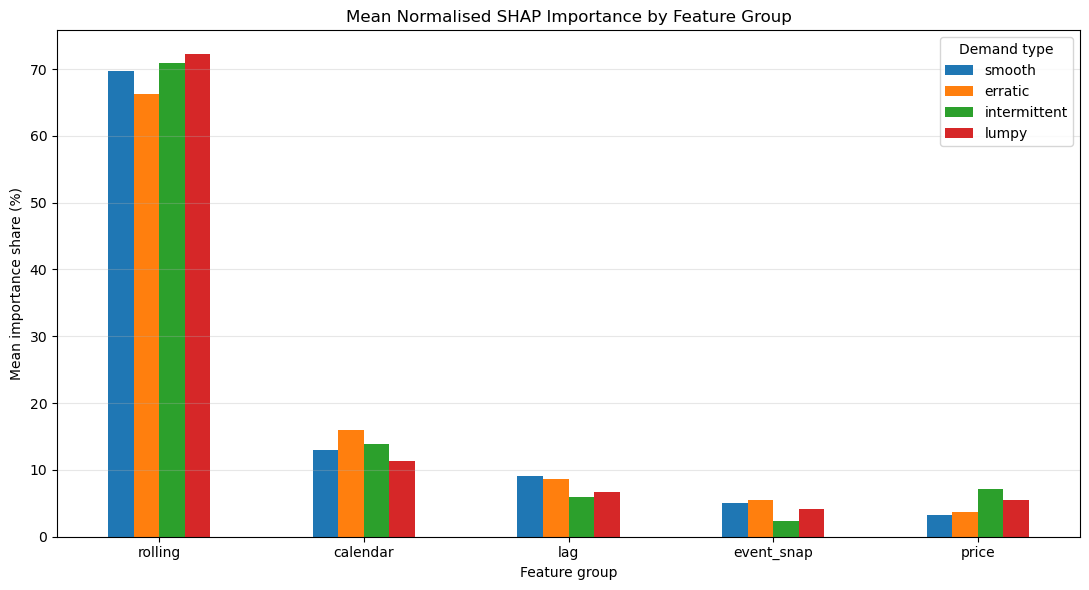

Saved:
C:\Users\gamec\Documents\MSc_Dissertation_M5\outputs\figures\step18\step18_group_importance_by_demand_type.png


In [13]:
# Cell 14: Plot feature-group SHAP importance

import matplotlib.pyplot as plt

group_plot_data = (
    shap_group_summary
    .pivot(
        index="feature_group",
        columns=DEMAND_TYPE_COLUMN,
        values="mean_importance_share",
    )
    .reindex(
        [
            "rolling",
            "calendar",
            "lag",
            "event_snap",
            "price",
        ]
    )
    .reindex(
        columns=DEMAND_TYPES
    )
    * 100
)

figure, axis = plt.subplots(
    figsize=(11, 6)
)

group_plot_data.plot(
    kind="bar",
    ax=axis,
)

axis.set_title(
    "Mean Normalised SHAP Importance by Feature Group"
)

axis.set_xlabel(
    "Feature group"
)

axis.set_ylabel(
    "Mean importance share (%)"
)

axis.tick_params(
    axis="x",
    rotation=0,
)

axis.legend(
    title="Demand type"
)

axis.grid(
    axis="y",
    alpha=0.3,
)

figure.tight_layout()

STEP18_GROUP_FIGURE_FILE = (
    STEP18_FIGURE_DIR
    / "step18_group_importance_by_demand_type.png"
)

figure.savefig(
    STEP18_GROUP_FIGURE_FILE,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:")
print(STEP18_GROUP_FIGURE_FILE)

### Individual Feature Importance Across Demand Types

The figure presents each feature's mean normalised SHAP importance for the four demand types. Features are ordered using their average importance across all demand types.

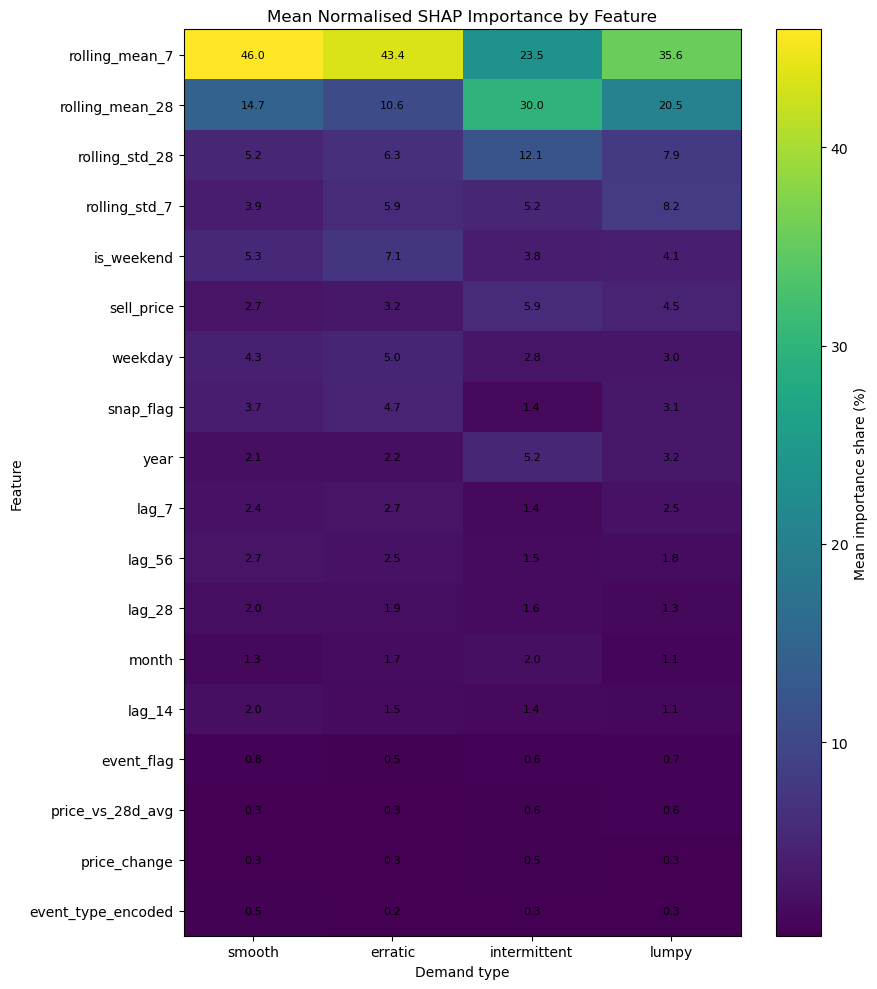

Saved:
C:\Users\gamec\Documents\MSc_Dissertation_M5\outputs\figures\step18\step18_feature_importance_matrix.png


In [14]:
# Cell 15: Plot the individual feature importance matrix

feature_plot_data = (
    shap_feature_summary
    .pivot(
        index="feature",
        columns=DEMAND_TYPE_COLUMN,
        values="mean_importance_share",
    )
    .reindex(
        columns=DEMAND_TYPES
    )
    * 100
)

feature_plot_data[
    "overall_mean"
] = (
    feature_plot_data.mean(
        axis=1
    )
)

feature_plot_data = (
    feature_plot_data
    .sort_values(
        "overall_mean",
        ascending=False,
    )
    .drop(
        columns="overall_mean"
    )
)

plot_matrix = (
    feature_plot_data.to_numpy(
        dtype=np.float64
    )
)

figure, axis = plt.subplots(
    figsize=(9, 10)
)

image = axis.imshow(
    plot_matrix,
    aspect="auto",
)

axis.set_title(
    "Mean Normalised SHAP Importance by Feature"
)

axis.set_xticks(
    np.arange(
        len(DEMAND_TYPES)
    )
)

axis.set_xticklabels(
    DEMAND_TYPES
)

axis.set_yticks(
    np.arange(
        len(feature_plot_data.index)
    )
)

axis.set_yticklabels(
    feature_plot_data.index
)

axis.set_xlabel(
    "Demand type"
)

axis.set_ylabel(
    "Feature"
)

for row_index in range(
    plot_matrix.shape[0]
):
    for column_index in range(
        plot_matrix.shape[1]
    ):
        axis.text(
            column_index,
            row_index,
            f"{plot_matrix[row_index, column_index]:.1f}",
            ha="center",
            va="center",
            fontsize=8,
        )

colour_bar = figure.colorbar(
    image,
    ax=axis,
)

colour_bar.set_label(
    "Mean importance share (%)"
)

figure.tight_layout()

STEP18_FEATURE_FIGURE_FILE = (
    STEP18_FIGURE_DIR
    / "step18_feature_importance_matrix.png"
)

figure.savefig(
    STEP18_FEATURE_FIGURE_FILE,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:")
print(STEP18_FEATURE_FIGURE_FILE)

### SHAP Reliance Compared with Ablation Performance

The figure compares mean SHAP importance with the change in WRMSSE after removing each feature group. Positive values on the vertical axis mean that removal worsened WRMSSE. Negative values mean that the reduced model achieved a lower mean WRMSSE.

The two measures answer different questions. SHAP describes how strongly the complete model used a feature group, while ablation measures the change in forecast performance after that group was removed.

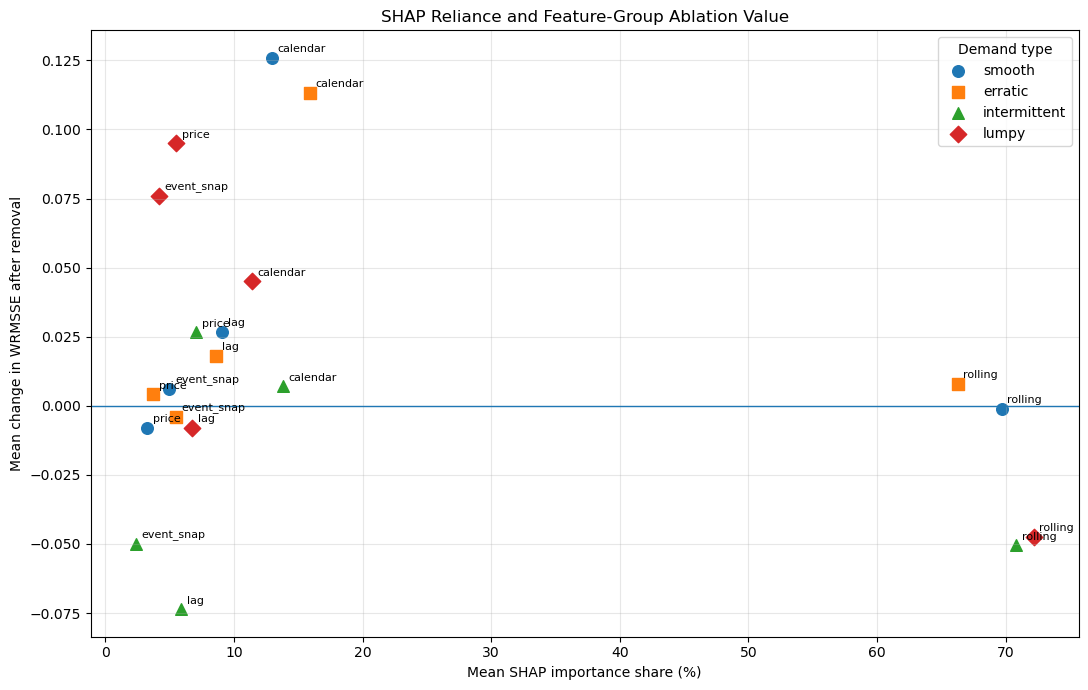

Saved:
C:\Users\gamec\Documents\MSc_Dissertation_M5\outputs\figures\step18\step18_shap_ablation_comparison.png


In [15]:
# Cell 16: Compare SHAP reliance with ablation value

marker_map = {
    "smooth": "o",
    "erratic": "s",
    "intermittent": "^",
    "lumpy": "D",
}

figure, axis = plt.subplots(
    figsize=(11, 7)
)

for demand_type in DEMAND_TYPES:
    plot_rows = (
        shap_ablation_comparison.loc[
            shap_ablation_comparison[
                DEMAND_TYPE_COLUMN
            ] == demand_type
        ]
    )

    axis.scatter(
        plot_rows[
            "mean_importance_percentage"
        ],
        plot_rows[
            "mean_delta_wrmsse"
        ],
        marker=marker_map[
            demand_type
        ],
        label=demand_type,
        s=70,
    )

    for _, plot_row in (
        plot_rows.iterrows()
    ):
        axis.annotate(
            plot_row[
                "feature_group"
            ],
            (
                plot_row[
                    "mean_importance_percentage"
                ],
                plot_row[
                    "mean_delta_wrmsse"
                ],
            ),
            xytext=(4, 4),
            textcoords="offset points",
            fontsize=8,
        )

axis.axhline(
    y=0,
    linewidth=1,
)

axis.set_title(
    "SHAP Reliance and Feature-Group Ablation Value"
)

axis.set_xlabel(
    "Mean SHAP importance share (%)"
)

axis.set_ylabel(
    "Mean change in WRMSSE after removal"
)

axis.grid(
    alpha=0.3,
)

axis.legend(
    title="Demand type"
)

figure.tight_layout()

STEP18_COMPARISON_FIGURE_FILE = (
    STEP18_FIGURE_DIR
    / "step18_shap_ablation_comparison.png"
)

figure.savefig(
    STEP18_COMPARISON_FIGURE_FILE,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:")
print(STEP18_COMPARISON_FIGURE_FILE)

## Step 18 Interpretation Log

| Finding | Verified evidence | Interpretation | Limitation |
|---|---|---|---|
| Rolling features had the highest SHAP importance for every demand type. | Their mean shares were 69.708% for smooth, 66.267% for erratic, 70.840% for intermittent and 72.190% for lumpy demand. The rolling group ranked first in all 20 models. | All four model families relied heavily on recent sales-level and variability summaries. | High SHAP reliance does not prove that the group improved forecast accuracy. |
| The leading individual feature differed for intermittent demand. | `rolling_mean_7` ranked first in all five folds for smooth, erratic and lumpy demand. `rolling_mean_28` ranked first in all five intermittent-demand folds. | The intermittent models relied more strongly on a longer sales-history summary than the other demand types. | SHAP does not establish why the models selected the longer window. |
| Calendar features ranked second for every demand type. | Mean calendar shares were 12.945% for smooth, 15.935% for erratic, 13.814% for intermittent and 11.392% for lumpy demand. | Calendar information contributed meaningfully to the complete models, although less than rolling features. | Individual calendar-feature importance varied across folds, especially for intermittent demand. |
| Smooth and erratic calendar findings were consistent with ablation. | Calendar removal increased mean WRMSSE by 0.125891 for smooth demand and 0.113205 for erratic demand. | Calendar features showed both model reliance and positive performance value for these demand types. | The comparison is descriptive and does not establish statistical significance. |
| Rolling-feature SHAP and ablation findings differed. | Rolling features had the highest SHAP share for all demand types, but their removal changed mean WRMSSE by -0.001118 for smooth, +0.007874 for erratic, -0.050413 for intermittent and -0.047435 for lumpy demand. | A model can rely strongly on a feature group even when overlapping retained features allow a reduced model to perform similarly or better. | The Step 17 ablated models were not separately retuned. |
| Intermittent lag findings were broadly consistent across methods. | Lag features represented 5.917% of mean SHAP importance, and lag removal improved WRMSSE in all five folds with a mean delta of -0.073589. | The complete intermittent models used lag features less than rolling features, while the ablation results suggested that retaining the lag group did not improve WRMSSE. | This does not prove that every individual lag feature was harmful. |
| Lumpy price features had limited SHAP share but strong ablation value. | Price features represented 5.502% of mean SHAP importance, but price removal increased mean WRMSSE by 0.094992 in all five folds. | A feature group can make a relatively small contribution to model output while still providing information that is difficult for the remaining groups to replace. | SHAP magnitude and ablation value are measured on different scales. |
| Lumpy event and SNAP features showed the same contrast. | Event and SNAP features represented 4.161% of mean SHAP importance, but their removal increased mean WRMSSE by 0.075897 in all five folds. | Lower overall reliance did not mean that the group lacked unique forecast value. | The analysis is performed at group level for ablation and individual-feature level for SHAP. |

## Step 18 Surprise Log

| Unexpected result | Verified evidence | Why it matters | Follow-up |
|---|---|---|---|
| Rolling features ranked first in all 20 SHAP models but were not consistently useful in the ablation study. | Rolling SHAP shares ranged from 59.248% to 80.599% across models, while mean ablation effects were negative for smooth, intermittent and lumpy demand. | Model reliance and forecast value are not interchangeable concepts. | Discuss the difference between conditional SHAP reliance and leave-one-group-out performance. |
| Lumpy price features had a relatively small SHAP share but the largest positive ablation effect. | Mean SHAP share was 5.502%, while price removal increased mean WRMSSE by 0.094992 and worsened all five folds. | A smaller contribution can still contain information that is difficult to replace. | Compare price findings with the rolling group in Chapter 5. |
| Lumpy event and SNAP features followed a similar pattern. | Mean SHAP share was 4.161%, but removal increased mean WRMSSE by 0.075897 in all five folds. | Low average reliance does not imply low predictive value. | Report this as a contrast, not as a contradiction or error. |
| The intermittent `year` feature was highly unstable across folds. | Its mean importance share was 5.208%, with a standard deviation of 6.962 percentage points and a range from 0.344% to 17.519%. | One forecast period strongly influenced its average importance. | Show fold variation and avoid presenting the mean alone as stable. |
| Intermittent demand was the only type where `rolling_mean_28` consistently ranked above `rolling_mean_7`. | `rolling_mean_28` ranked first in all five intermittent folds, while `rolling_mean_7` ranked first in the other 15 models. | Demand type changed which sales-history window the models relied on most. | Use this as direct evidence for demand-type-specific feature behaviour. |

In [16]:
# Cell 19: Final Step 18 completion audit

import json

print("Running the final Step 18 completion audit")
print("-" * 70)

# Check that all required notebook objects were created
# before the final audit begins.
required_object_names = [
    "pilot_shap_check_table",
    "completion_check_table",
    "full_shap_check_table",
    "summary_check_table",
    "comparison_check_table",
    "report_summary_check_table",
    "shap_model_audit",
    "shap_feature_results",
    "shap_group_results",
    "shap_detail",
    "shap_feature_summary",
    "shap_group_summary",
    "shap_ablation_comparison",
    "step18_report_summary",
    "SHAP_MODEL_AUDIT_FILE",
    "SHAP_FEATURE_RESULTS_FILE",
    "SHAP_GROUP_RESULTS_FILE",
    "SHAP_COMPLETION_AUDIT_FILE",
    "SHAP_DETAIL_FILE",
    "SHAP_ABLATION_COMPARISON_FILE",
    "STEP18_REPORT_SUMMARY_FILE",
    "STEP18_GROUP_FIGURE_FILE",
    "STEP18_FEATURE_FIGURE_FILE",
    "STEP18_COMPARISON_FIGURE_FILE",
]

missing_notebook_objects = [
    object_name
    for object_name in required_object_names
    if object_name not in globals()
]

if missing_notebook_objects:
    raise NameError(
        "The following Step 18 objects have not been created:\n- "
        + "\n- ".join(missing_notebook_objects)
    )

# Remove temporary progress files left by Cell 9.
partial_output_files = [
    STEP18_TABLE_DIR
    / "step18_model_audit_partial.csv",
    STEP18_TABLE_DIR
    / "step18_feature_importance_partial.csv",
    STEP18_TABLE_DIR
    / "step18_group_importance_partial.csv",
]

removed_partial_files = []

for partial_file in partial_output_files:
    if partial_file.exists():
        partial_file.unlink()
        removed_partial_files.append(
            partial_file
        )

# Find the 20 model-specific SHAP files.
individual_detail_files = sorted(
    STEP18_RESULT_DIR.glob(
        "step18_shap_fold*_*.parquet"
    )
)

# Save a record of the final Step 18 design.
STEP18_CONFIGURATION_FILE = (
    STEP18_TABLE_DIR
    / "step18_configuration.json"
)

step18_configuration = {
    "step": 18,
    "analysis": (
        "Native XGBoost TreeSHAP analysis "
        "by demand type"
    ),
    "models": 20,
    "folds": 5,
    "demand_types": DEMAND_TYPES,
    "features": FULL_MODEL_FEATURES,
    "feature_groups": FEATURE_GROUPS,
    "outer_test_rows": 112_000,
    "rows_per_model": 5_600,
    "series_per_model": 200,
    "forecast_horizon": 28,
    "shap_method": (
        "Exact native XGBoost pred_contribs"
    ),
    "importance_measure": (
        "Mean absolute SHAP contribution"
    ),
    "normalisation": (
        "Importance shares were normalised "
        "separately for each fold and demand type "
        "before averaging across folds."
    ),
    "output_scale": (
        "XGBoost raw model-margin scale"
    ),
    "forecast_reconstruction": (
        "Observed training sales and stored recursive "
        "predictions were used. Actual outer-test sales "
        "were not used to construct recursive features."
    ),
    "causal_interpretation": False,
    "random_seed": SEED,
}

with open(
    STEP18_CONFIGURATION_FILE,
    "w",
    encoding="utf-8",
) as configuration_file:
    json.dump(
        step18_configuration,
        configuration_file,
        indent=4,
    )

# Define all outputs that must exist before Step 18
# can be considered complete.
required_step18_outputs = [
    SHAP_MODEL_AUDIT_FILE,
    SHAP_FEATURE_RESULTS_FILE,
    SHAP_GROUP_RESULTS_FILE,
    SHAP_COMPLETION_AUDIT_FILE,
    SHAP_DETAIL_FILE,
    STEP18_TABLE_DIR
    / "step18_pilot_feature_importance.csv",
    STEP18_TABLE_DIR
    / "step18_pilot_group_importance.csv",
    STEP18_TABLE_DIR
    / "step18_pilot_shap_audit.csv",
    STEP18_TABLE_DIR
    / "step18_feature_summary_by_demand_type.csv",
    STEP18_TABLE_DIR
    / "step18_group_summary_by_demand_type.csv",
    STEP18_TABLE_DIR
    / "step18_top_ten_features_by_demand_type.csv",
    SHAP_ABLATION_COMPARISON_FILE,
    STEP18_REPORT_SUMMARY_FILE,
    STEP18_GROUP_FIGURE_FILE,
    STEP18_FEATURE_FIGURE_FILE,
    STEP18_COMPARISON_FIGURE_FILE,
    STEP18_CONFIGURATION_FILE,
]

missing_required_outputs = [
    output_file
    for output_file in required_step18_outputs
    if not Path(output_file).exists()
]

empty_required_outputs = [
    output_file
    for output_file in required_step18_outputs
    if (
        Path(output_file).exists()
        and Path(output_file).stat().st_size == 0
    )
]

remaining_partial_files = [
    partial_file
    for partial_file in partial_output_files
    if partial_file.exists()
]

maximum_forecast_difference = float(
    shap_model_audit[
        "maximum_forecast_difference"
    ].max()
)

maximum_additivity_difference = float(
    shap_model_audit[
        "maximum_additivity_difference"
    ].max()
)

individual_detail_row_total = sum(
    len(
        pd.read_parquet(
            detail_file,
            columns=[
                "fold",
            ],
        )
    )
    for detail_file in individual_detail_files
)

# Confirm that every earlier audit passed.
audit_table_checks = {
    "Pilot SHAP audit passed": (
        pilot_shap_check_table[
            "passed"
        ].all()
    ),
    "20-model run audit passed": (
        completion_check_table[
            "passed"
        ].all()
    ),
    "Complete SHAP audit passed": (
        full_shap_check_table[
            "passed"
        ].all()
    ),
    "Demand-type summary audit passed": (
        summary_check_table[
            "passed"
        ].all()
    ),
    "SHAP-ablation comparison passed": (
        comparison_check_table[
            "passed"
        ].all()
    ),
    "Report summary audit passed": (
        report_summary_check_table[
            "passed"
        ].all()
    ),
}

# Confirm the final tables, forecasts and files.
result_checks = {
    "20 model audit rows": (
        len(shap_model_audit) == 20
    ),
    "Five folds represented": (
        shap_model_audit[
            "fold"
        ].nunique() == 5
    ),
    "Four demand types represented": (
        set(
            shap_model_audit[
                DEMAND_TYPE_COLUMN
            ]
        ) == set(DEMAND_TYPES)
    ),
    "360 feature-level rows": (
        len(shap_feature_results) == 360
    ),
    "18 features per model": (
        shap_feature_results
        .groupby(
            [
                "fold",
                DEMAND_TYPE_COLUMN,
            ],
            observed=True,
        )["feature"]
        .nunique()
        .eq(18)
        .all()
    ),
    "100 feature-group rows": (
        len(shap_group_results) == 100
    ),
    "Five groups per model": (
        shap_group_results
        .groupby(
            [
                "fold",
                DEMAND_TYPE_COLUMN,
            ],
            observed=True,
        )["feature_group"]
        .nunique()
        .eq(5)
        .all()
    ),
    "112,000 combined SHAP rows": (
        len(shap_detail) == 112_000
    ),
    "No duplicate combined SHAP rows": (
        shap_detail.duplicated(
            subset=[
                "fold",
                DEMAND_TYPE_COLUMN,
                SERIES_COLUMN,
                DATE_COLUMN,
            ]
        ).sum() == 0
    ),
    "72 demand-type feature rows": (
        len(shap_feature_summary) == 72
    ),
    "20 demand-type group rows": (
        len(shap_group_summary) == 20
    ),
    "20 SHAP-ablation rows": (
        len(shap_ablation_comparison) == 20
    ),
    "Four report-summary rows": (
        len(step18_report_summary) == 4
    ),
    "20 individual detail files": (
        len(individual_detail_files) == 20
    ),
    "112,000 rows across individual files": (
        individual_detail_row_total == 112_000
    ),
    "No required output missing": (
        len(missing_required_outputs) == 0
    ),
    "No required output is empty": (
        len(empty_required_outputs) == 0
    ),
    "No partial files remain": (
        len(remaining_partial_files) == 0
    ),
    "All forecasts reproduced exactly": (
        maximum_forecast_difference == 0.0
    ),
    "Maximum additivity difference below 1e-4": (
        maximum_additivity_difference < 1e-4
    ),
    "All feature shares are valid": (
        shap_feature_results[
            "importance_share"
        ].between(
            0,
            1,
            inclusive="both",
        ).all()
    ),
    "All group shares are valid": (
        shap_group_results[
            "importance_share"
        ].between(
            0,
            1,
            inclusive="both",
        ).all()
    ),
    "All three figures exist": (
        all(
            Path(figure_file).exists()
            for figure_file in [
                STEP18_GROUP_FIGURE_FILE,
                STEP18_FEATURE_FIGURE_FILE,
                STEP18_COMPARISON_FIGURE_FILE,
            ]
        )
    ),
}

completion_audit_checks = {
    **audit_table_checks,
    **result_checks,
}

step18_completion_audit = pd.DataFrame(
    {
        "check": (
            completion_audit_checks.keys()
        ),
        "passed": (
            completion_audit_checks.values()
        ),
    }
)

display(step18_completion_audit)

print()
print("Step 18 output audit")
print("-" * 70)
print(
    "Required output files:",
    len(required_step18_outputs),
)
print(
    "Individual SHAP files:",
    len(individual_detail_files),
)
print(
    "Rows across individual files:",
    f"{individual_detail_row_total:,}",
)
print(
    "Partial files removed:",
    len(removed_partial_files),
)
print(
    "Missing required outputs:",
    [
        str(path)
        for path in missing_required_outputs
    ],
)
print(
    "Empty required outputs:",
    [
        str(path)
        for path in empty_required_outputs
    ],
)
print(
    "Remaining partial outputs:",
    [
        str(path)
        for path in remaining_partial_files
    ],
)
print(
    "Maximum forecast difference:",
    f"{maximum_forecast_difference:.12e}",
)
print(
    "Maximum additivity difference:",
    f"{maximum_additivity_difference:.12e}",
)

failed_final_checks = [
    check
    for check, passed
    in completion_audit_checks.items()
    if not passed
]

if failed_final_checks:
    raise AssertionError(
        "Step 18 completion audit failed:\n- "
        + "\n- ".join(
            failed_final_checks
        )
    )

STEP18_FINAL_AUDIT_FILE = (
    STEP18_TABLE_DIR
    / "step18_completion_audit.csv"
)

step18_completion_audit.to_csv(
    STEP18_FINAL_AUDIT_FILE,
    index=False,
)

if not STEP18_FINAL_AUDIT_FILE.exists():
    raise FileNotFoundError(
        "The final Step 18 completion-audit file "
        "was not saved."
    )

if STEP18_FINAL_AUDIT_FILE.stat().st_size == 0:
    raise AssertionError(
        "The final Step 18 completion-audit file is empty."
    )

print()
print("Step 18 completion audit passed.")
print("Saved:")
print(STEP18_FINAL_AUDIT_FILE)

Running the final Step 18 completion audit
----------------------------------------------------------------------


,check,passed
0,Pilot SHAP audit passed,True
1,20-model run audit passed,True
2,Complete SHAP audit passed,True
3,Demand-type summary audit passed,True
4,SHAP-ablation comparison passed,True
5,Report summary audit passed,True
6,20 model audit rows,True
7,Five folds represented,True
8,Four demand types represented,True
9,360 feature-level rows,True



Step 18 output audit
----------------------------------------------------------------------
Required output files: 17
Individual SHAP files: 20
Rows across individual files: 112,000
Partial files removed: 3
Missing required outputs: []
Empty required outputs: []
Remaining partial outputs: []
Maximum forecast difference: 0.000000000000e+00
Maximum additivity difference: 2.194428816438e-05

Step 18 completion audit passed.
Saved:
C:\Users\gamec\Documents\MSc_Dissertation_M5\outputs\tables\step18\step18_completion_audit.csv
